<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/GPT_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 GPT 완전정복
> 인용구 추가

> 인용구 추가





> **"다음 단어를 끝없이 예측하는 AI, GPT를 배워봅시다"**

## 🌟 이 노트북에서 배울 것
- **GPT가 무엇인지** 비유를 통해 이해하기
- **GPT가 어떻게 글을 생성하는지** 단계별로 살펴보기
- **실습 4가지** 직접 만들어보기:
  1. ✍️ **텍스트 생성**: 이야기/시를 GPT가 이어 쓰기
  2. 💬 **챗봇 만들기**: 간단한 대화 시스템
  3. 📝 **요약 & 번역**: Few-shot 학습으로 다양한 작업
  4. 💻 **코드 생성 / QA**: 코드와 질문 답변 자동화

## 📌 이 노트북의 특징
- ✅ **친근한 비유**로 어려운 개념도 쉽게
- ✅ **풍부한 시각화**로 눈으로 보고 이해
- ✅ **빈칸 채우기 실습**으로 직접 코드 작성
- ✅ **단계별 퀴즈**로 이해도 점검
- ✅ **Google Colab** 환경에서 바로 실행 가능

> 💡 **참고**: Transformer와 BERT를 먼저 공부하고 오시면 더 이해가 잘 됩니다!
> GPT는 Transformer의 **디코더(Decoder) 부분만** 가져다 쓰는 모델이에요.

---

## 📚 전체 목차
| 섹션 | 제목 | 핵심 내용 |
|------|------|----------|
| 1 | 🛠️ 환경 설정 | 라이브러리 설치 |
| 2 | 🤔 GPT가 뭔가요? | 개념과 BERT와의 차이 |
| 3 | 🧩 BPE 토크나이저 | 단어를 쪼개는 또 다른 방법 |
| 4 | 🏗️ GPT 구조 | Decoder-only & 인과 마스킹 |
| 5 | 🎲 사전학습 (다음 단어 예측) | Next Token Prediction |
| 6 | 🌡️ 텍스트 생성 방법 | Greedy/Beam/Sampling |
| 7 | ✍️ 실습 1: 이야기·시 생성 | Text Generation |
| 8 | 💬 실습 2: 챗봇 만들기 | 대화형 AI |
| 9 | 📝 실습 3: 요약 & 번역 | Few-shot Learning |
| 10 | 💻 실습 4: 코드/QA 생성 | 실용 응용 |
| 11 | 🎯 프롬프트 엔지니어링 | Zero/Few-shot, CoT |
| 12 | 🚀 GPT 가족과 ChatGPT | GPT-1~4, RLHF |


---
# 1️⃣ 환경 설정

## 🛠️ 필요한 도구들

| 도구 | 역할 | 비유 |
|------|------|------|
| `transformers` | GPT 모델 자체 | 🧠 두뇌 |
| `torch` | 계산 엔진 | ⚙️ 모터 |
| `matplotlib` | 그래프 그리기 | 🎨 그림 도구 |
| `tiktoken` | OpenAI 토크나이저 | ✂️ 가위 |

> 💡 **Colab 사용자**: GPU 런타임을 선택하시면 더 빠르게 실행됩니다.
> (런타임 → 런타임 유형 변경 → GPU)

In [1]:
# 📦 필수 라이브러리 설치
!pip install -q transformers torch matplotlib seaborn tiktoken

print("✅ 설치 완료!")

✅ 설치 완료!


In [2]:
# 📚 라이브러리 불러오기
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import GPT2Tokenizer, GPT2LMHeadModel, pipeline

# 한글 폰트 + 음수 부호 + 수식 폰트 (1-4 패턴)
import subprocess
try:
    subprocess.run(['apt-get','-qq','install','fonts-nanum'], check=False)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
except Exception as e:
    print(f"폰트 생략: {e}")

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 사용 장치: {device}")
print(f"🔥 PyTorch 버전: {torch.__version__}")

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

🖥️ 사용 장치: cpu
🔥 PyTorch 버전: 2.10.0+cpu


### ✅ 체크포인트 1
설치와 라이브러리 로딩이 끝났습니다! GPT를 다룰 준비 완료. 🎉

---
# 2️⃣ GPT가 뭔가요?

## 🤔 GPT를 한 문장으로 말하면?

> **"다음 단어를 끝없이 예측해서 문장을 만들어가는 AI"**

**G**enerative **P**re-trained **T**ransformer
= **생성형**으로 **사전학습된** **트랜스포머**

## 📱 비유: 스마트폰 자동완성

여러분이 스마트폰으로 "오늘 점심..."이라고 입력하면 키보드 위에 추천 단어들이 뜨죠?

> "오늘 점심..." → [밥, 메뉴, 약속, 뭐, ...]

**GPT는 이것의 슈퍼 진화 버전**입니다!

- 단어 하나가 아니라 **문장 전체**를 만들어냄
- 일반 자동완성보다 **훨씬 똑똑하고 길게** 생성

## ✍️ 비유: 한 글자씩 책을 써내려가는 작가

GPT는 **한 단어**를 쓰면, 그것까지 포함해서 다시 다음 단어를 예측합니다.

```
"옛날" → "옛날 옛적에"
       → "옛날 옛적에 한"
       → "옛날 옛적에 한 마을에"
       → "옛날 옛적에 한 마을에 살던"
       → ...
```

이렇게 **한 글자씩 누적**하면서 글을 완성하는 방식을 **자기회귀(Autoregressive)** 라고 해요.

## 🆚 GPT vs BERT 비교

| 특징 | GPT | BERT |
|------|-----|------|
| **방향** | 왼쪽 → 오른쪽 한 방향 | ↔️ 양방향 |
| **구조** | Transformer **디코더** | Transformer **인코더** |
| **학습 목표** | 다음 단어 예측 | 빈칸 채우기 (MLM) |
| **잘 하는 것** | ✍️ **생성** (글쓰기, 대화) | 🧐 **이해** (분류, 추출) |
| **대표 응용** | ChatGPT, GitHub Copilot | 검색, 감정 분석 |

## 🎯 비유로 다시

| 모델 | 비유 |
|------|------|
| **BERT** | 책을 좌우로 훑어보며 **빈칸을 채우는** 학생 📖 |
| **GPT** | 한 글자씩 **차례로 글을 쓰는** 작가 ✍️ |

> 💡 두 모델의 장단점이 명확히 달라요!
> BERT는 이해를 잘하고, GPT는 생성을 잘합니다.

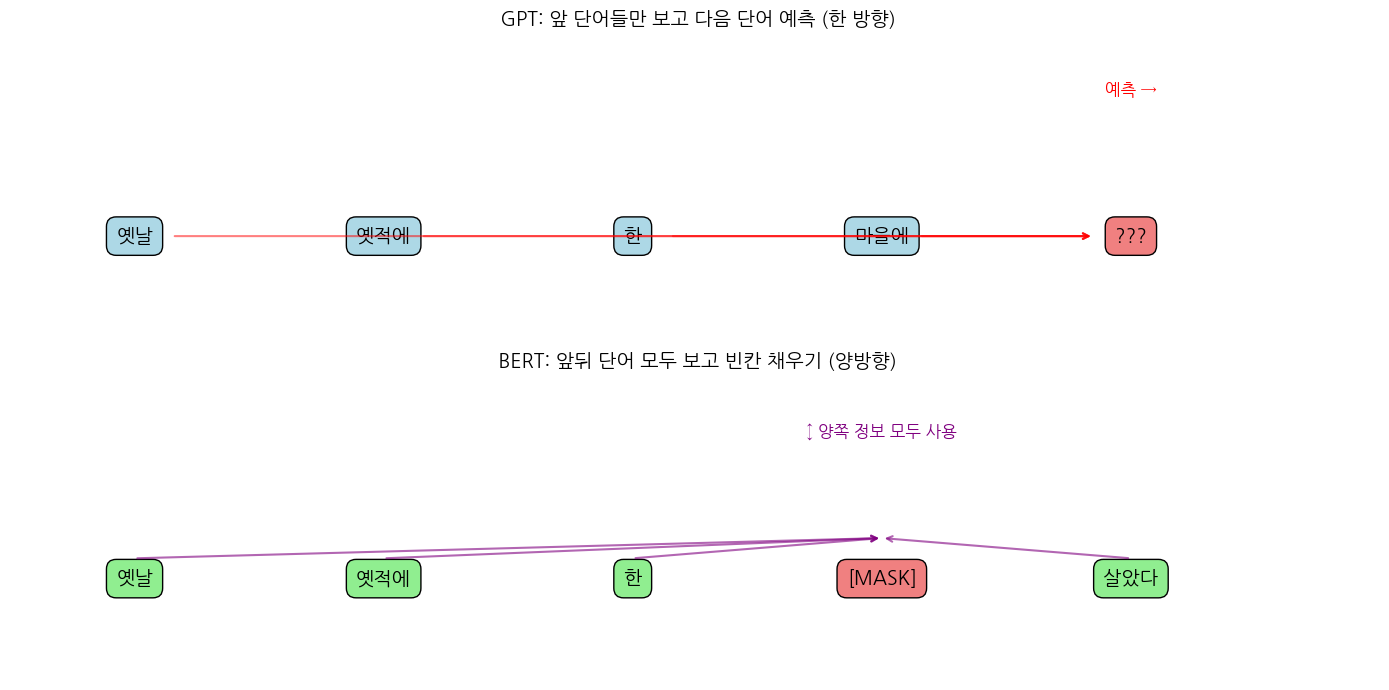


💡 GPT는 '글쓰기'에, BERT는 '이해하기'에 강합니다!


In [3]:
# 🎨 GPT vs BERT 작동 방식 비교 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# GPT: 단방향, 다음 단어 예측
ax1 = axes[0]
words_gpt = ['옛날', '옛적에', '한', '마을에', '?']
for i, w in enumerate(words_gpt):
    color = 'lightcoral' if i == 4 else 'lightblue'
    label = '???' if i == 4 else w
    ax1.text(i, 0.5, label, ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='black'))

# 화살표 (왼→오 만)
for i in range(4):
    ax1.annotate('', xy=(4-0.15, 0.5), xytext=(i+0.15, 0.5),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.5))

ax1.text(4, 1.2, '예측 →', ha='center', fontsize=12, color='red', fontweight='bold')
ax1.set_xlim(-0.5, 5)
ax1.set_ylim(0, 1.5)
ax1.set_title(' GPT: 앞 단어들만 보고 다음 단어 예측 (한 방향)',
              fontsize=14, fontweight='bold')
ax1.axis('off')

# BERT: 양방향, 가운데 빈칸
ax2 = axes[1]
words_bert = ['옛날', '옛적에', '한', '?', '살았다']
for i, w in enumerate(words_bert):
    color = 'lightcoral' if i == 3 else 'lightgreen'
    label = '[MASK]' if i == 3 else w
    ax2.text(i, 0.5, label, ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='black'))

# 양쪽 화살표
for i in [0, 1, 2, 4]:
    ax2.annotate('', xy=(3, 0.7), xytext=(i, 0.6),
                 arrowprops=dict(arrowstyle='->', color='purple', lw=1.5, alpha=0.6))

ax2.text(3, 1.2, '↕ 양쪽 정보 모두 사용', ha='center', fontsize=12, color='purple', fontweight='bold')
ax2.set_xlim(-0.5, 5)
ax2.set_ylim(0, 1.5)
ax2.set_title(' BERT: 앞뒤 단어 모두 보고 빈칸 채우기 (양방향)',
              fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n💡 GPT는 '글쓰기'에, BERT는 '이해하기'에 강합니다!")

## 🧠 퀴즈 #1

다음 중 GPT의 특징이 **아닌** 것은?

- A) 다음 단어를 예측하면서 학습한다
- B) Transformer의 디코더 부분을 사용한다
- C) 빈칸을 양쪽 문맥으로 채운다
- D) 문장을 생성하는 데 강하다

<details>
<summary>👉 정답 보기</summary>

**C) 빈칸을 양쪽 문맥으로 채운다**
- 그건 BERT의 특징입니다!
- GPT는 항상 **왼쪽에서 오른쪽으로**만 보면서 다음 단어를 예측해요.

</details>

---
# 3️⃣ BPE 토크나이저

## ✂️ 토큰화 다시 한번

> **"문장을 컴퓨터가 다룰 수 있는 숫자 ID로 바꾸기"**

BERT는 **WordPiece**를 썼지만, GPT는 **BPE (Byte Pair Encoding)** 를 사용해요.

## 🧩 BPE란?

> **"자주 같이 등장하는 글자 쌍을 묶어가며 사전을 만드는 방법"**

### 비유: 레고 블록 만들기 🧱

처음엔 글자 하나하나가 블록입니다:
```
['a', 'b', 'c', ..., 'z']
```

자주 같이 나타나는 쌍을 합쳐 새로운 블록으로 추가:
```
['a', 'b', ..., 'th', 'er', 'ing', 'tion', ...]
```

계속 합치면:
```
['the', 'and', 'play', 'machine', 'learning', ...]
```

## 🎯 BPE의 장점

- **모르는 단어 없음!** 어떤 단어든 글자 단위로 쪼개서 표현 가능
- **이모지·특수문자**도 처리 가능
- **다국어** 처리에 유리

In [4]:
# 🔧 GPT-2 토크나이저 불러오기
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# 패딩 토큰을 EOS로 설정 (GPT는 기본 패딩이 없음)
tokenizer.pad_token = tokenizer.eos_token

print(f"📊 어휘 사전 크기: {tokenizer.vocab_size:,}개 토큰")
print(f"🎯 특수 토큰들:")
print(f"   EOS (문장 끝): '{tokenizer.eos_token}' (ID: {tokenizer.eos_token_id})")
print(f"   BOS (문장 시작): '{tokenizer.bos_token}' (ID: {tokenizer.bos_token_id})")
print(f"   UNK (모르는 단어): '{tokenizer.unk_token}'")
print()
print("💡 GPT는 BERT의 [CLS]/[SEP]가 없어요! 그냥 자연스럽게 이어서 생성합니다.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

📊 어휘 사전 크기: 50,257개 토큰
🎯 특수 토큰들:
   EOS (문장 끝): '<|endoftext|>' (ID: 50256)
   BOS (문장 시작): '<|endoftext|>' (ID: 50256)
   UNK (모르는 단어): '<|endoftext|>'

💡 GPT는 BERT의 [CLS]/[SEP]가 없어요! 그냥 자연스럽게 이어서 생성합니다.


In [5]:
# 🧪 BPE 토큰화 실험
sentences = [
    "I love machine learning!",
    "Tokenization is interesting.",
    "GPT generates text.",
    "Playing football is fun."
]

for sent in sentences:
    tokens = tokenizer.tokenize(sent)
    ids = tokenizer.encode(sent)
    print(f"📝 원문: {sent}")
    print(f"🧩 토큰: {tokens}")
    print(f"🔢 ID: {ids}")
    print(f"   ({len(tokens)}개 토큰)")
    print("-" * 60)

📝 원문: I love machine learning!
🧩 토큰: ['I', 'Ġlove', 'Ġmachine', 'Ġlearning', '!']
🔢 ID: [40, 1842, 4572, 4673, 0]
   (5개 토큰)
------------------------------------------------------------
📝 원문: Tokenization is interesting.
🧩 토큰: ['Token', 'ization', 'Ġis', 'Ġinteresting', '.']
🔢 ID: [30642, 1634, 318, 3499, 13]
   (5개 토큰)
------------------------------------------------------------
📝 원문: GPT generates text.
🧩 토큰: ['G', 'PT', 'Ġgenerates', 'Ġtext', '.']
🔢 ID: [38, 11571, 18616, 2420, 13]
   (5개 토큰)
------------------------------------------------------------
📝 원문: Playing football is fun.
🧩 토큰: ['Playing', 'Ġfootball', 'Ġis', 'Ġfun', '.']
🔢 ID: [36530, 4346, 318, 1257, 13]
   (5개 토큰)
------------------------------------------------------------


## 🔍 GPT 토큰의 특이한 점: 'Ġ' 표시

GPT 토큰을 보면 `Ġ` 같은 이상한 글자가 보일 거예요. 이게 뭘까요?

### 'Ġ' = **단어 앞의 공백** 표시!

| 토큰 | 의미 |
|------|------|
| `the` | 문장 시작 부분의 "the" |
| `Ġthe` | 공백 뒤의 " the" |

이렇게 **공백 정보까지 토큰에 포함**시켜서, 단어 사이 띄어쓰기를 정확히 복원할 수 있어요!

> 💡 BPE의 똑똑한 설계 - 공백 처리를 토큰화 단계에서 함께 해결합니다.

/tmp/ipykernel_19555/3778427303.py:33: UserWarning: Glyph 288 (\N{LATIN CAPITAL LETTER G WITH DOT ABOVE}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 288 (\N{LATIN CAPITAL LETTER G WITH DOT ABOVE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


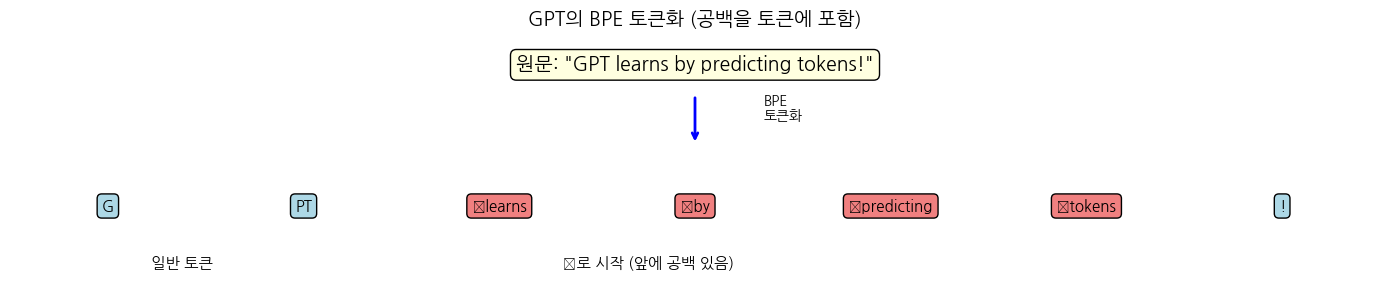


💡 총 7개 토큰으로 쪼개졌어요.
💡 'Ġ'는 단어 앞 공백이라는 뜻이에요!


In [6]:
# 🎨 토큰화 결과 시각화
sentence = "GPT learns by predicting tokens!"
tokens = tokenizer.tokenize(sentence)

fig, ax = plt.subplots(figsize=(14, 3))

# 원문
ax.text(0.5, 0.85, f'원문: "{sentence}"',
        ha='center', fontsize=14, transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow'))

# 화살표
ax.annotate('', xy=(0.5, 0.55), xytext=(0.5, 0.75),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(0.55, 0.65, 'BPE\n토큰화', transform=ax.transAxes, fontsize=10)

# 토큰
n = len(tokens)
for i, t in enumerate(tokens):
    color = 'lightcoral' if t.startswith('Ġ') else 'lightblue'
    x = (i + 0.5) / n
    ax.text(x, 0.3, t, ha='center', va='center', fontsize=11,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='black'))

# 범례
ax.text(0.1, 0.05, ' 일반 토큰', transform=ax.transAxes, fontsize=11)
ax.text(0.4, 0.05, ' Ġ로 시작 (앞에 공백 있음)', transform=ax.transAxes, fontsize=11)

ax.axis('off')
plt.title('GPT의 BPE 토큰화 (공백을 토큰에 포함)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n💡 총 {n}개 토큰으로 쪼개졌어요.")
print(f"💡 'Ġ'는 단어 앞 공백이라는 뜻이에요!")

In [7]:
# 🔬 신기한 토큰화 예시들

# 예시 1: 흔하지 않은 단어
weird = "Antidisestablishmentarianism"
print(f"📝 '{weird}'")
print(f"🧩 {tokenizer.tokenize(weird)}")
print(f"   ({len(tokenizer.tokenize(weird))}개 토큰)\n")

# 예시 2: 숫자
numbers = "I have 1234567890 apples"
print(f"📝 '{numbers}'")
print(f"🧩 {tokenizer.tokenize(numbers)}\n")

# 예시 3: 이모지/특수문자
emoji = "Hello 😀 world!"
print(f"📝 '{emoji}'")
print(f"🧩 {tokenizer.tokenize(emoji)}\n")

# 예시 4: 한국어 (영어 GPT-2는 한국어가 약함)
korean = "안녕하세요"
print(f"📝 '{korean}' (한국어)")
print(f"🧩 {tokenizer.tokenize(korean)}")
print(f"   ↑ 한 글자가 여러 바이트로 쪼개짐 (영어 GPT-2의 한계)")

📝 'Antidisestablishmentarianism'
🧩 ['Ant', 'idis', 'establishment', 'arian', 'ism']
   (5개 토큰)

📝 'I have 1234567890 apples'
🧩 ['I', 'Ġhave', 'Ġ123', '45', '678', '90', 'Ġapples']

📝 'Hello 😀 world!'
🧩 ['Hello', 'ĠðŁĺ', 'Ģ', 'Ġworld', '!']

📝 '안녕하세요' (한국어)
🧩 ['ì', 'ķ', 'Ī', 'ë', 'ħ', 'ķ', 'íķ', 'ĺ', 'ì', 'Ħ', '¸', 'ì', 'ļ', 'Ķ']
   ↑ 한 글자가 여러 바이트로 쪼개짐 (영어 GPT-2의 한계)


## 🎯 빈칸 채우기 실습 #1

원문을 토큰으로 만들고, 다시 원문으로 복원해보세요!

In [8]:
# 🎯 실습 #1: 인코딩 & 디코딩
text = "GPT is amazing for text generation."

# TODO: 1. 문장을 토큰 ID로 인코딩하세요
ids = tokenizer.encode(text)

# TODO: 2. 토큰 ID들을 다시 텍스트로 디코딩하세요
decoded = tokenizer.decode(ids)

print(f"원문: {text}")
print(f"IDs:  {ids}")
print(f"복원: {decoded}")
print()
print(f"✅ 원문과 복원본이 같나요? {text == decoded}")

원문: GPT is amazing for text generation.
IDs:  [38, 11571, 318, 4998, 329, 2420, 5270, 13]
복원: GPT is amazing for text generation.

✅ 원문과 복원본이 같나요? True


<details>
<summary>🔑 정답 보기</summary>

```python
ids = tokenizer.encode(text)
decoded = tokenizer.decode(ids)
```

- `tokenizer.encode()`: 텍스트 → ID 리스트
- `tokenizer.decode()`: ID 리스트 → 텍스트
- BPE는 손실 없이 정확히 복원됩니다!

</details>

### ✅ 체크포인트 2

지금까지 배운 것:
- GPT는 **다음 단어를 예측**하는 자기회귀 모델
- GPT vs BERT: **단방향 vs 양방향**, **생성 vs 이해**
- **BPE 토크나이저**는 글자 쌍을 합쳐가며 사전 구축
- `Ġ` 기호는 **앞 공백** 표시


---
# 4️⃣ GPT의 구조 (Decoder-only)

## 🏗️ Transformer의 절반만 사용

원래 Transformer는 **인코더 + 디코더** 두 부분이었어요.

| 모델 | 인코더 | 디코더 |
|------|--------|--------|
| **원래 Transformer** | ✅ | ✅ |
| **BERT** | ✅ | ❌ |
| **GPT** | ❌ | ✅ |

> 💡 GPT는 디코더만 가져다가 살짝 변형해서 사용합니다.

## 🧱 GPT 블록의 구조

```
입력 토큰
   ↓
[토큰 임베딩 + 위치 임베딩]
   ↓
─────────── (N번 반복) ───────────
│  1) 인과 마스킹된 셀프 어텐션  │
│  2) 피드포워드 네트워크         │
│  3) 잔차 연결 + LayerNorm      │
─────────────────────────────────
   ↓
[다음 단어 확률 분포]
```

비유: **N개의 똑같은 층을 쌓아올린 빌딩** 🏢

## 🔑 핵심: 인과 마스킹 (Causal Mask)

### "미래를 못 보게 가리기"

GPT는 다음 단어를 예측해야 해요. 그런데 학습할 때 정답이 이미 다 있다면?

> 🤔 "정답을 보고 답하는 셈"이 되어버립니다!

그래서 **현재 위치 이후의 단어들을 가려서** 미래를 못 보게 합니다.

### 비유: 시험지 가리기 📝

수능 영어 빈칸 문제를 풀 때, **뒤의 정답지를 손으로 가리고** 풀듯이!

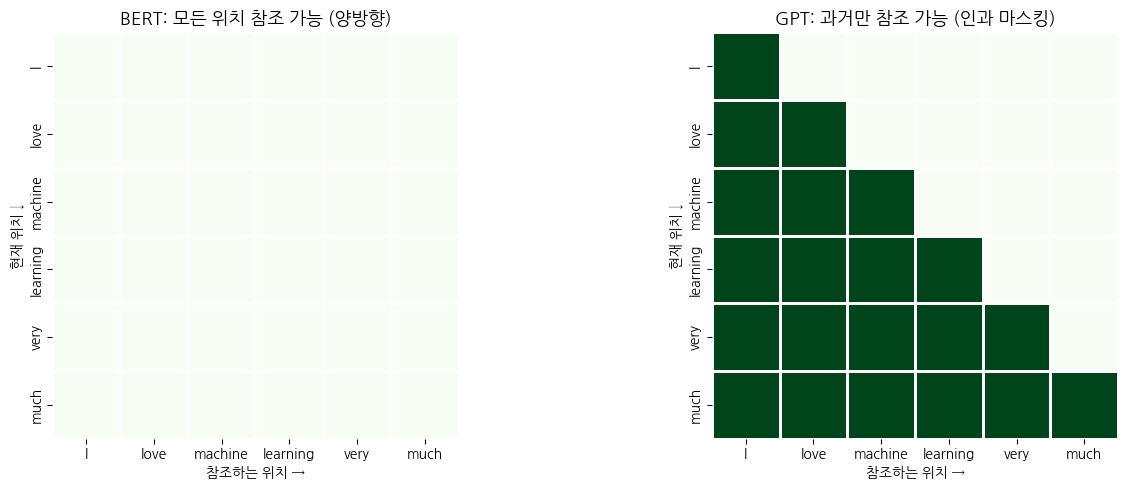


💡 GPT는 자기 자신과 그 이전 단어들만 봅니다.
💡 'learning'을 처리할 때는 'I, love, machine, learning'만 볼 수 있어요!


In [9]:
# 🎨 인과 마스킹 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 마스크가 없을 때 (BERT 스타일)
ax1 = axes[0]
mask_no = np.ones((6, 6))
sns.heatmap(mask_no, ax=ax1, cmap='Greens', cbar=False,
            xticklabels=['I', 'love', 'machine', 'learning', 'very', 'much'],
            yticklabels=['I', 'love', 'machine', 'learning', 'very', 'much'],
            linewidths=1, square=True)
ax1.set_title('BERT: 모든 위치 참조 가능 (양방향)', fontsize=13, fontweight='bold')
ax1.set_xlabel('참조하는 위치 →')
ax1.set_ylabel('현재 위치 ↓')

# 마스크가 있을 때 (GPT 스타일)
ax2 = axes[1]
mask_causal = np.tril(np.ones((6, 6)))
sns.heatmap(mask_causal, ax=ax2, cmap='Greens', cbar=False,
            xticklabels=['I', 'love', 'machine', 'learning', 'very', 'much'],
            yticklabels=['I', 'love', 'machine', 'learning', 'very', 'much'],
            linewidths=1, square=True)
ax2.set_title('GPT: 과거만 참조 가능 (인과 마스킹)', fontsize=13, fontweight='bold')
ax2.set_xlabel('참조하는 위치 →')
ax2.set_ylabel('현재 위치 ↓')

plt.tight_layout()
plt.show()

print("\n💡 GPT는 자기 자신과 그 이전 단어들만 봅니다.")
print("💡 'learning'을 처리할 때는 'I, love, machine, learning'만 볼 수 있어요!")

In [10]:
# 🔬 직접 인과 마스크 만들어보기
def create_causal_mask(seq_len):
    """하삼각 행렬로 인과 마스크 생성"""
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask

# 5개 토큰 시퀀스에 대한 마스크
mask = create_causal_mask(5)
print("🧱 인과 마스크 (5x5):")
print(mask.numpy())
print()
print("💡 1은 '볼 수 있음', 0은 '못 봄'")
print("💡 위쪽 삼각형(미래)은 모두 0, 아래쪽 삼각형(과거)은 1")

🧱 인과 마스크 (5x5):
[[1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1.]]

💡 1은 '볼 수 있음', 0은 '못 봄'
💡 위쪽 삼각형(미래)은 모두 0, 아래쪽 삼각형(과거)은 1


## 🔬 GPT 어텐션이 실제로 어떻게 작동하나?

### 비유: 회의실의 일방향 발언권

상상해보세요. 회의실에 6명이 차례로 앉아있고:
- 1번 사람: 자기 의견만 말함
- 2번 사람: **1번이 한 말을 듣고** 의견
- 3번 사람: **1, 2번이 한 말을 듣고** 의견
- ...
- 6번 사람: **1~5번이 한 말을 모두 듣고** 의견

이것이 바로 GPT의 **인과적 어텐션**입니다!

> 💡 각 토큰은 자기 자신과 그 이전 토큰들의 정보만 활용해서 다음 단어를 예측해요.

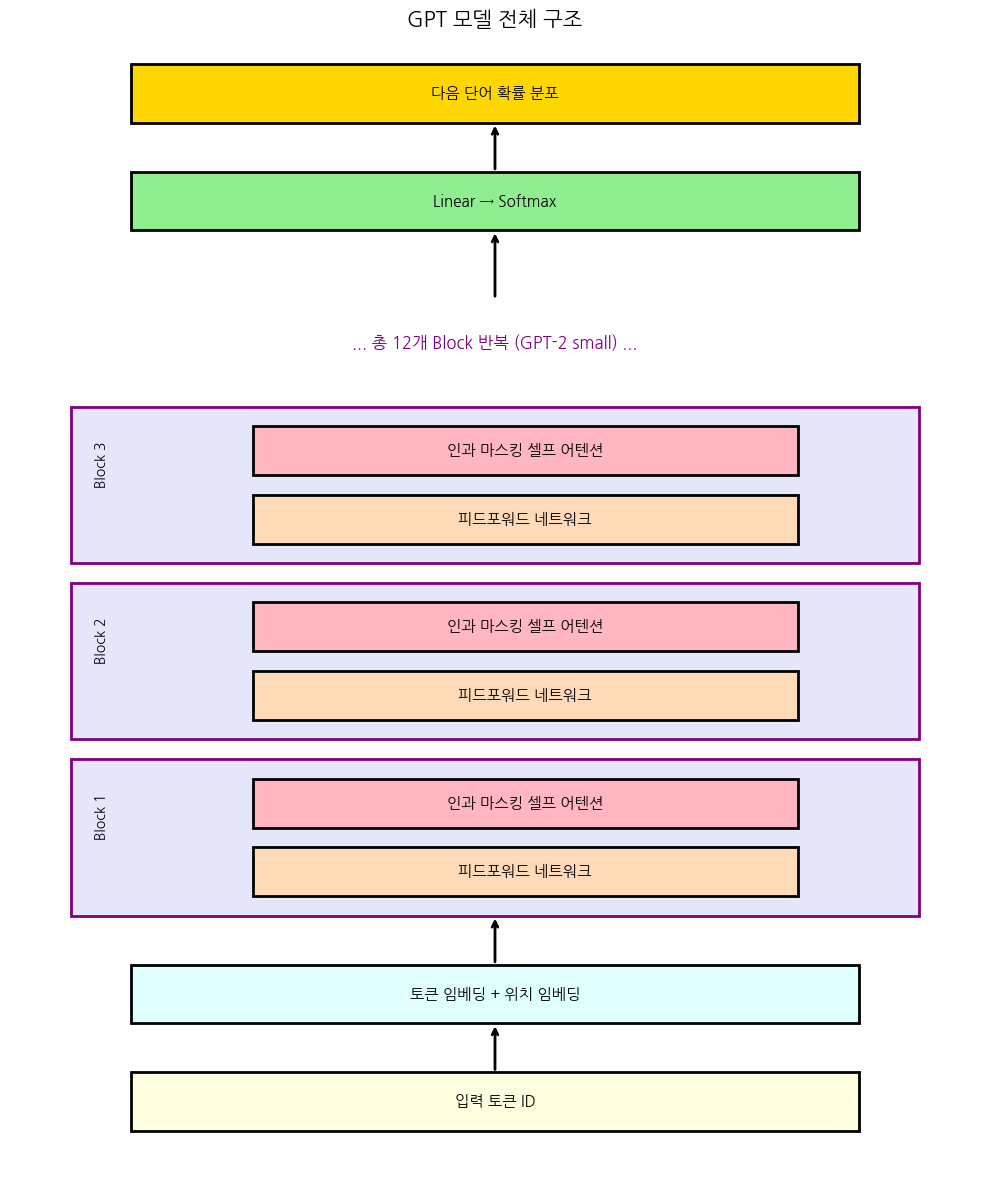

In [11]:
# 🎨 GPT 구조 다이어그램
fig, ax = plt.subplots(figsize=(10, 12))

# 박스 그리는 헬퍼
def draw_box(ax, x, y, w, h, text, color='lightblue', edge='black'):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, edgecolor=edge, linewidth=2))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=11, fontweight='bold')

# 입력
draw_box(ax, 1, 0.5, 6, 0.6, '입력 토큰 ID', 'lightyellow')

# 화살표
ax.annotate('', xy=(4, 1.6), xytext=(4, 1.1), arrowprops=dict(arrowstyle='->', lw=2))

# 임베딩
draw_box(ax, 1, 1.6, 6, 0.6, '토큰 임베딩 + 위치 임베딩', 'lightcyan')

# 화살표
ax.annotate('', xy=(4, 2.7), xytext=(4, 2.2), arrowprops=dict(arrowstyle='->', lw=2))

# Transformer 블록들 (12개 표현)
for i in range(3):
    y_base = 2.7 + i * 1.8

    # 큰 박스
    ax.add_patch(plt.Rectangle((0.5, y_base), 7, 1.6, facecolor='lavender',
                                edgecolor='purple', linewidth=2))
    ax.text(0.7, y_base + 0.8, f'Block {i+1}', fontsize=10, fontweight='bold', rotation=90)

    # 안의 컴포넌트
    draw_box(ax, 2, y_base + 0.9, 4.5, 0.5, '인과 마스킹 셀프 어텐션', '#FFB6C1')
    draw_box(ax, 2, y_base + 0.2, 4.5, 0.5, '피드포워드 네트워크', '#FFDAB9')

# "...12개 반복..." 표시
ax.text(4, 8.5, '... 총 12개 Block 반복 (GPT-2 small) ...',
        ha='center', fontsize=12, style='italic', color='purple')

# 화살표
ax.annotate('', xy=(4, 9.7), xytext=(4, 9.0), arrowprops=dict(arrowstyle='->', lw=2))

# Linear + Softmax
draw_box(ax, 1, 9.7, 6, 0.6, 'Linear → Softmax', 'lightgreen')

# 화살표
ax.annotate('', xy=(4, 10.8), xytext=(4, 10.3), arrowprops=dict(arrowstyle='->', lw=2))

# 출력
draw_box(ax, 1, 10.8, 6, 0.6, '다음 단어 확률 분포', 'gold')

ax.set_xlim(0, 8)
ax.set_ylim(0, 11.7)
ax.set_aspect('auto')
ax.axis('off')
plt.title('GPT 모델 전체 구조', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 GPT 모델 사이즈 비교

| 모델 | 출시 | 파라미터 | 레이어 수 |
|------|------|---------|----------|
| GPT-1 | 2018 | 1.17억 | 12 |
| GPT-2 small | 2019 | 1.24억 | 12 |
| GPT-2 medium | 2019 | 3.55억 | 24 |
| GPT-2 large | 2019 | 7.74억 | 36 |
| GPT-3 | 2020 | **1,750억** | 96 |
| GPT-4 | 2023 | 비공개 (~수조 추정) | 비공개 |

> 💡 우리는 Colab에서 가볍게 돌아가는 **GPT-2 small (1억 2400만 파라미터)** 을 사용합니다.

In [12]:
# 🏗️ GPT-2 모델 불러오기 & 구조 살펴보기
model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
model.eval()

# 모델 크기 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"📊 GPT-2 (small) 정보")
print(f"   총 파라미터: {total_params:,}개 (약 {total_params/1e6:.1f}M)")
print(f"   레이어 수: {model.config.n_layer}개")
print(f"   어텐션 헤드: {model.config.n_head}개")
print(f"   임베딩 차원: {model.config.n_embd}")
print(f"   최대 시퀀스 길이: {model.config.n_positions}")
print(f"   어휘 크기: {model.config.vocab_size:,}")
print()
print("💡 12개 블록이 위로 쌓여있고, 각 블록은 12개 어텐션 헤드를 갖고 있어요!")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

📊 GPT-2 (small) 정보
   총 파라미터: 124,439,808개 (약 124.4M)
   레이어 수: 12개
   어텐션 헤드: 12개
   임베딩 차원: 768
   최대 시퀀스 길이: 1024
   어휘 크기: 50,257

💡 12개 블록이 위로 쌓여있고, 각 블록은 12개 어텐션 헤드를 갖고 있어요!


---
# 5️⃣ 사전학습: 다음 단어 예측

## 🎲 GPT는 어떻게 학습하나요?

> **"방대한 텍스트에서 끝없이 다음 단어 맞히기 게임"**

### 학습 데이터
- 수백 GB의 인터넷 텍스트
- 책, 위키피디아, 뉴스, 블로그 등

### 학습 방법

**한 문장 안에서도 모든 위치마다 학습!**

문장: "나는 학교에 갔다"

| 입력 | 정답 (다음 단어) |
|------|-----------------|
| "나는" | "학교에" |
| "나는 학교에" | "갔다" |

이렇게 한 문장에서 **여러 번의 학습 데이터**가 만들어집니다!

## 📚 비유: 한 줄씩 가린 책 읽기

```
"옛날 옛적에 [한] 마을에 살았다"
        ↑ 여기 단어를 맞춰라!

"옛날 옛적에 한 [마을에] 살았다"
              ↑ 다음 단어 맞춰라!
```

이렇게 가린 위치만 바꿔가며 학습.

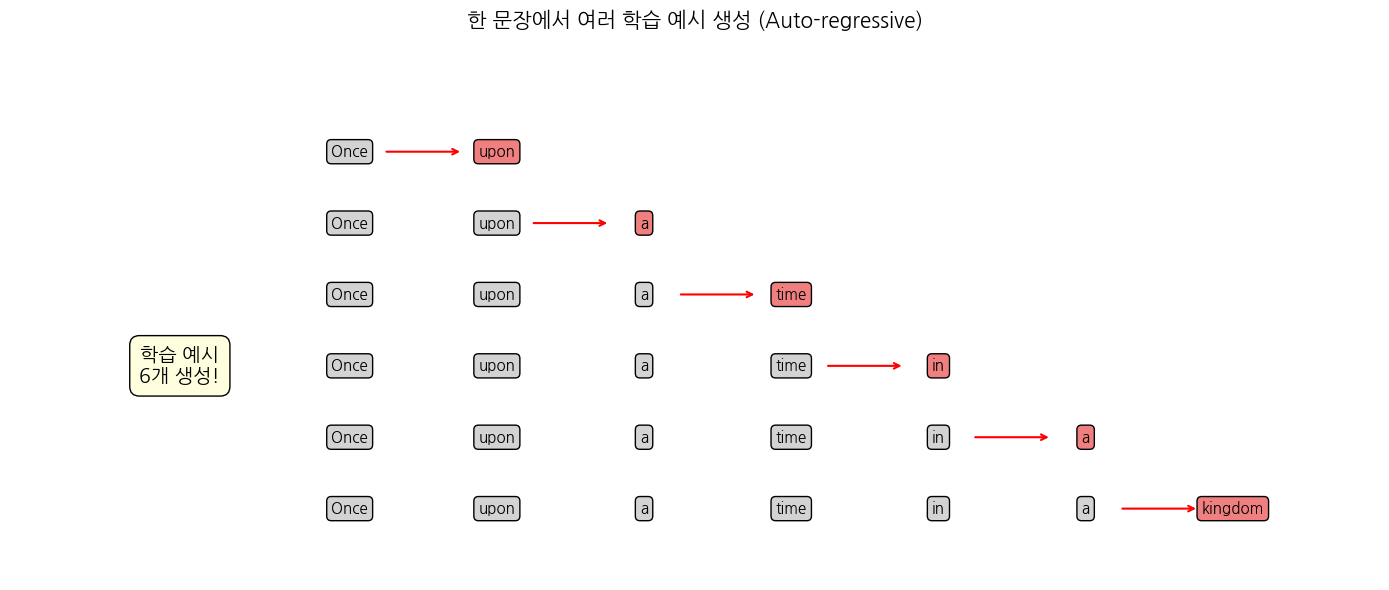


💡 7개 단어 문장에서 6개의 학습 데이터가 생성되었어요!
💡 이런 식으로 수십억 문장을 학습하면 GPT가 됩니다.


In [13]:
# 🎨 다음 단어 예측 학습 과정 시각화
fig, ax = plt.subplots(figsize=(14, 6))

sentence = ['Once', 'upon', 'a', 'time', 'in', 'a', 'kingdom']
n = len(sentence)

# 각 위치마다 입력/정답 표시
for i in range(n - 1):
    y = (n - i - 1) * 0.8

    # 입력 부분 (회색)
    for j, w in enumerate(sentence[:i+1]):
        ax.text(j*1.3, y, w, ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray'))

    # 화살표
    ax.annotate('', xy=((i+1)*1.3 - 0.3, y), xytext=(i*1.3 + 0.3, y),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

    # 정답 (빨강)
    ax.text((i+1)*1.3, y, sentence[i+1], ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral'))

ax.text(-1.5, (n-1)*0.8/2, '학습 예시\n6개 생성!', ha='center', va='center',
        fontsize=14, fontweight='bold', rotation=0,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow'))

ax.set_xlim(-3, n*1.3)
ax.set_ylim(0, n*0.8 + 0.5)
ax.axis('off')
plt.title('한 문장에서 여러 학습 예시 생성 (Auto-regressive)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 7개 단어 문장에서 6개의 학습 데이터가 생성되었어요!")
print("💡 이런 식으로 수십억 문장을 학습하면 GPT가 됩니다.")

In [14]:
# 🔬 GPT-2로 실제 다음 단어 예측해보기
prompt = "The cat sat on the"

# 토큰화
inputs = tokenizer(prompt, return_tensors='pt').to(device)

# 모델 출력
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits  # (1, seq_len, vocab_size)

# 마지막 토큰 위치의 출력 → 다음 단어 예측
next_token_logits = logits[0, -1, :]
next_token_probs = F.softmax(next_token_logits, dim=-1)

# 상위 10개 후보
top_k = 10
top_probs, top_ids = torch.topk(next_token_probs, top_k)

print(f"📝 프롬프트: \"{prompt} ___\"")
print(f"🎯 GPT-2가 예측한 다음 토큰 (상위 {top_k}개):")
print()
for i, (prob, tok_id) in enumerate(zip(top_probs, top_ids)):
    word = tokenizer.decode([tok_id.item()])
    bar = "█" * int(prob.item() * 50)
    print(f"   {i+1:2d}. {word:15s} {prob.item():.4f} {bar}")

📝 프롬프트: "The cat sat on the ___"
🎯 GPT-2가 예측한 다음 토큰 (상위 10개):

    1.  floor          0.0764 ███
    2.  bed            0.0653 ███
    3.  couch          0.0541 ██
    4.  ground         0.0521 ██
    5.  edge           0.0478 ██
    6.  bench          0.0316 █
    7.  table          0.0315 █
    8.  sofa           0.0288 █
    9.  other          0.0199 
   10.  back           0.0190 


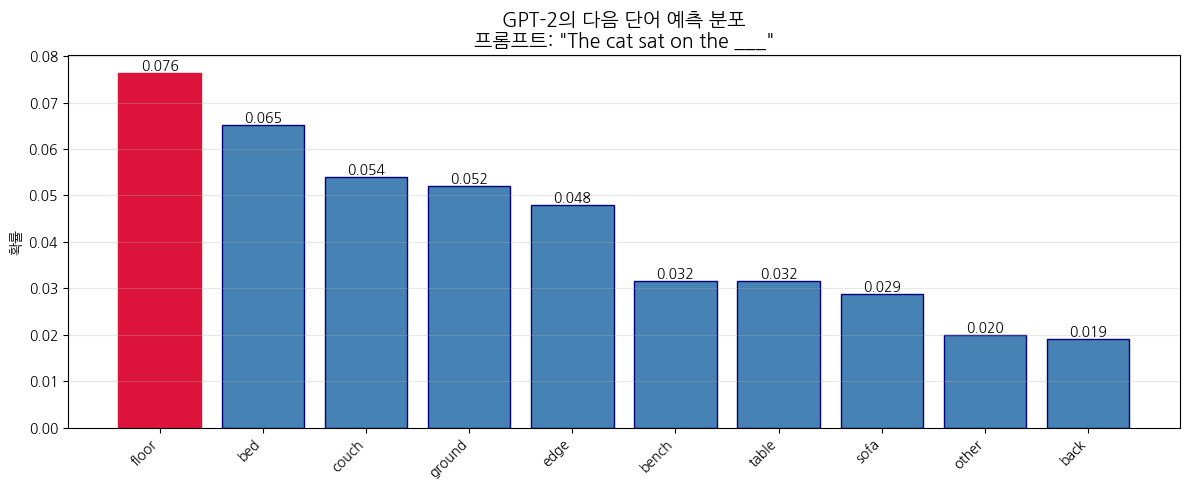


🏆 가장 높은 확률: 'floor' (0.0764)
💡 GPT는 이 분포에서 다음 단어를 선택합니다!


In [15]:
# 🎨 다음 단어 확률 분포 시각화
import matplotlib.pyplot as plt

words = [tokenizer.decode([tid.item()]).strip() for tid in top_ids]
probs = top_probs.cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(top_k), probs, color='steelblue', edgecolor='navy')
# 1위는 다른 색
bars[0].set_color('crimson')

ax.set_xticks(range(top_k))
ax.set_xticklabels(words, rotation=45, ha='right')
ax.set_ylabel('확률')
ax.set_title(f'GPT-2의 다음 단어 예측 분포\n프롬프트: "{prompt} ___"',
             fontsize=14, fontweight='bold')

# 확률 값 표시
for bar, prob in zip(bars, probs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{prob:.3f}', ha='center', va='bottom', fontsize=10)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n🏆 가장 높은 확률: '{words[0]}' ({probs[0]:.4f})")
print(f"💡 GPT는 이 분포에서 다음 단어를 선택합니다!")

## 🎯 빈칸 채우기 실습 #2

직접 프롬프트를 만들어서 GPT의 다음 단어 예측을 확인해보세요!

In [18]:
# 🎯 실습 #2: 직접 다음 단어 예측
my_prompt = "I went to the store to buy some"

# TODO: 1. my_prompt를 토큰화하세요 (return_tensors='pt' 사용)
inputs = tokenizer(my_prompt, return_tensors='pt').to(device)

# TODO: 2. 모델에 입력하여 출력 받기
with torch.no_grad():
    outputs = model(**inputs)

# 마지막 위치의 로짓 추출
last_logits = outputs.logits[0, -1, :]

# TODO: 3. softmax로 확률 계산하기 (F.softmax 사용)
probs = F.softmax(last_logits, dim=-1)

# 상위 5개 추출
top_probs, top_ids = torch.topk(probs, 5)

print(f"📝 프롬프트: \"{my_prompt} ___\"")
print(f"🎯 상위 5개 예측:")
for prob, tid in zip(top_probs, top_ids):
    word = tokenizer.decode([tid.item()])
    print(f"   '{word}' (확률 {prob:.3f})")

📝 프롬프트: "I went to the store to buy some ___"
🎯 상위 5개 예측:
   ' food' (확률 0.033)
   ' stuff' (확률 0.024)
   ' of' (확률 0.024)
   '.' (확률 0.023)
   ' new' (확률 0.022)


<details>
<summary>🔑 정답 보기</summary>

```python
inputs = tokenizer(my_prompt, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = model(**inputs)

probs = F.softmax(last_logits, dim=-1)
```

- `tokenizer(text, return_tensors='pt')`: 텍스트를 PyTorch 텐서로 변환
- `model(**inputs)`: 딕셔너리를 인자로 풀어서 전달
- `F.softmax(logits, dim=-1)`: 마지막 차원에 대해 softmax 적용

</details>

### ✅ 체크포인트 3

지금까지 배운 것:
- GPT는 Transformer **디코더만** 사용
- **인과 마스킹**으로 미래 단어를 가려서 학습
- 한 문장에서 **여러 학습 데이터** 생성 (자기회귀)
- 출력은 **다음 단어의 확률 분포**

다음은 **확률 분포에서 단어를 어떻게 선택하는가** (생성 전략)입니다! 🌡️

---
# 6️⃣ 텍스트 생성 방법 (Sampling 전략)

## 🌡️ 같은 GPT라도 답이 달라진다?

GPT의 출력은 **확률 분포**예요. 어떻게 단어를 뽑느냐에 따라 생성된 글이 완전히 달라집니다!

## 🎯 5가지 주요 생성 전략

### 1️⃣ Greedy Search (탐욕 검색)
- 매번 **가장 확률 높은 단어** 1개만 선택
- **장점**: 빠름, 일관적
- **단점**: 지루하고 반복적

비유: **항상 안전한 선택만** 하는 사람 😐

### 2️⃣ Beam Search (빔 서치)
- 여러 후보 경로(빔)를 동시에 탐색하다가 최종 선택
- **장점**: Greedy보다 자연스러움
- **단점**: 여전히 반복 문제, 창의성 부족

비유: **여러 길을 동시에 가보고** 가장 좋은 길 선택 🛤️

### 3️⃣ Random Sampling (무작위 샘플링)
- 확률에 따라 **랜덤하게** 단어 선택
- **장점**: 다양함
- **단점**: 너무 이상한 단어 나올 수 있음

비유: **주사위 굴려서** 결정 🎲

### 4️⃣ Top-k Sampling
- **상위 k개 단어** 중에서만 샘플링
- 예: k=50이면 1~50등 안에서만 뽑기

비유: **상위 k명 후보** 중에서 뽑기 🎯

### 5️⃣ Top-p (Nucleus) Sampling
- 확률 합이 p가 될 때까지의 단어 중에서 샘플링
- 예: p=0.9면 상위 누적 90%까지만

비유: **합쳐서 p% 차지하는 핵심 후보**에서만 🎪

## 🌡️ Temperature: 창의성 조절 다이얼

> **"높을수록 모험적, 낮을수록 안전하게"**

### Temperature 작동 원리

확률 분포를 **평탄하게** (T 높음) 또는 **뾰족하게** (T 낮음) 만듭니다.

| Temperature | 효과 | 비유 |
|------------|------|------|
| **0.1** (낮음) | 거의 항상 1등 선택 | 보수적 ❄️ |
| **0.7** (중간) | 다양하면서도 자연스러움 | 균형 🌤️ |
| **1.5** (높음) | 의외의 단어도 자주 선택 | 창의적 🔥 |

### 예시: "오늘 날씨가" 다음에 올 단어

- **T=0.1**: 항상 "좋다" → 매번 같은 답
- **T=0.7**: "좋다", "나쁘다", "맑다", "흐리다" 중 적절히
- **T=1.5**: "좋다", "신비롭다", "춤춘다", "노란색" 같은 의외의 단어도!

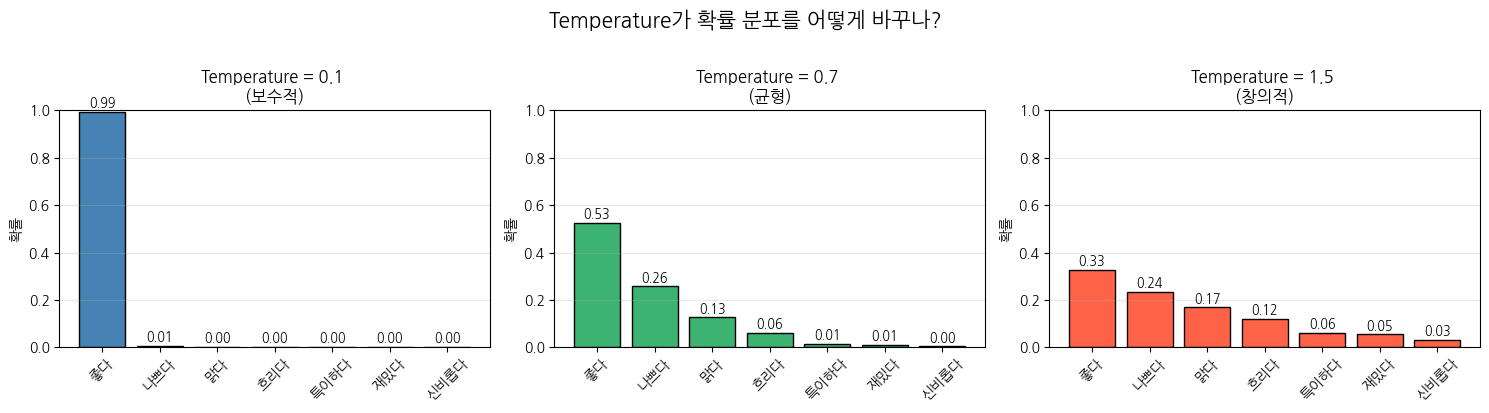


💡 Temperature 낮음: 1등 단어가 거의 1.0에 가까운 확률 → 거의 같은 답만
💡 Temperature 높음: 모든 단어가 비슷한 확률 → 의외의 단어도 나옴


In [19]:
# 🎨 Temperature가 확률 분포에 미치는 영향
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 원본 logits
words = ['좋다', '나쁘다', '맑다', '흐리다', '특이하다', '재밌다', '신비롭다']
original_logits = np.array([3.0, 2.5, 2.0, 1.5, 0.5, 0.3, -0.5])

temperatures = [0.1, 0.7, 1.5]
titles = ['Temperature = 0.1 \n(보수적)',
          'Temperature = 0.7 \n(균형)',
          'Temperature = 1.5 \n(창의적)']
colors = ['steelblue', 'mediumseagreen', 'tomato']

for ax, T, title, color in zip(axes, temperatures, titles, colors):
    # Temperature 적용: logits / T 후 softmax
    scaled = original_logits / T
    probs = np.exp(scaled) / np.exp(scaled).sum()

    ax.bar(words, probs, color=color, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('확률')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

    # 확률 값 표시
    for i, p in enumerate(probs):
        ax.text(i, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)

    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Temperature가 확률 분포를 어떻게 바꾸나?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Temperature 낮음: 1등 단어가 거의 1.0에 가까운 확률 → 거의 같은 답만")
print("💡 Temperature 높음: 모든 단어가 비슷한 확률 → 의외의 단어도 나옴")

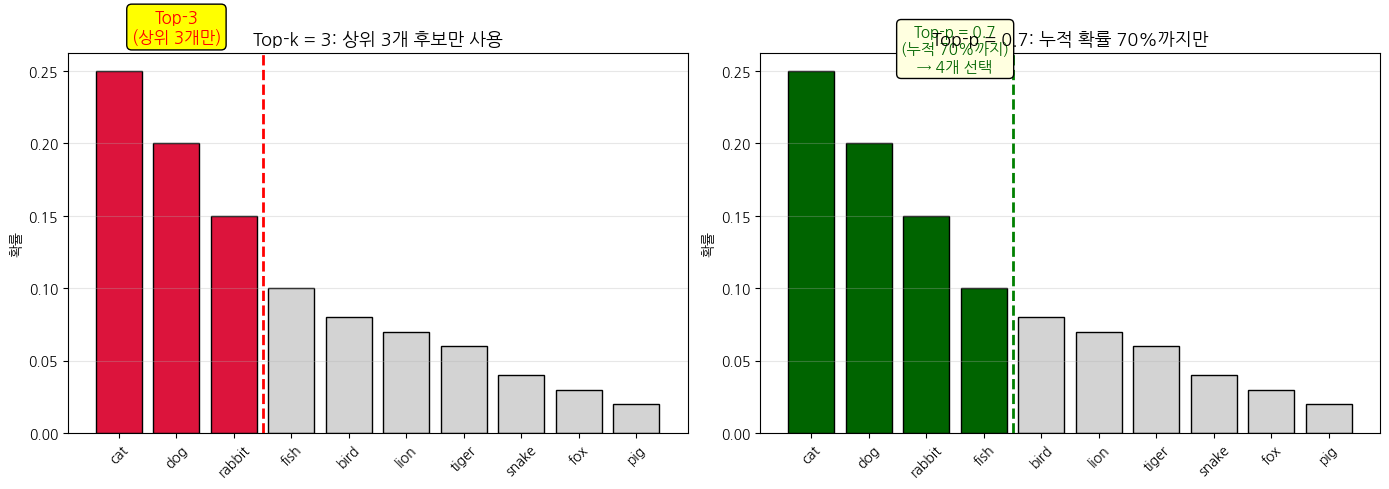


💡 Top-k: 고정된 개수만 사용 (분포 모양에 무관)
💡 Top-p: 분포 모양에 따라 적응적으로 후보 수 변경


In [20]:
# 🎨 Top-k와 Top-p 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 가상의 확률 분포 (이미 정렬됨)
words_full = ['cat', 'dog', 'rabbit', 'fish', 'bird', 'lion', 'tiger', 'snake', 'fox', 'pig']
probs_full = np.array([0.25, 0.20, 0.15, 0.10, 0.08, 0.07, 0.06, 0.04, 0.03, 0.02])

# Top-k = 3
ax1 = axes[0]
colors_k = ['crimson' if i < 3 else 'lightgray' for i in range(len(words_full))]
ax1.bar(words_full, probs_full, color=colors_k, edgecolor='black')
ax1.axvline(x=2.5, color='red', linestyle='--', lw=2)
ax1.text(1, 0.27, 'Top-3\n(상위 3개만)', ha='center', fontsize=12, fontweight='bold', color='red',
         bbox=dict(boxstyle='round', facecolor='yellow'))
ax1.set_title('Top-k = 3: 상위 3개 후보만 사용', fontsize=13, fontweight='bold')
ax1.set_ylabel('확률')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Top-p = 0.7
ax2 = axes[1]
cumsum = np.cumsum(probs_full)
cutoff_idx = np.argmax(cumsum >= 0.7) + 1  # 0.7 넘는 첫 인덱스 +1
colors_p = ['darkgreen' if i < cutoff_idx else 'lightgray' for i in range(len(words_full))]
ax2.bar(words_full, probs_full, color=colors_p, edgecolor='black')
ax2.axvline(x=cutoff_idx - 0.5, color='green', linestyle='--', lw=2)
ax2.text(2.5, 0.25, f'Top-p = 0.7\n(누적 70%까지)\n→ {cutoff_idx}개 선택',
         ha='center', fontsize=11, fontweight='bold', color='darkgreen',
         bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax2.set_title('Top-p = 0.7: 누적 확률 70%까지만', fontsize=13, fontweight='bold')
ax2.set_ylabel('확률')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 Top-k: 고정된 개수만 사용 (분포 모양에 무관)")
print("💡 Top-p: 분포 모양에 따라 적응적으로 후보 수 변경")

In [21]:
# 🔬 같은 프롬프트로 다양한 전략 비교
prompt = "Once upon a time in a small village,"
inputs = tokenizer(prompt, return_tensors='pt').to(device)

print(f"📝 프롬프트: \"{prompt}\"")
print("=" * 70)

# 1) Greedy
torch.manual_seed(42)
output = model.generate(**inputs, max_new_tokens=30, do_sample=False,
                        pad_token_id=tokenizer.eos_token_id)
text = tokenizer.decode(output[0], skip_special_tokens=True)
print("\n🎯 Greedy Search:")
print(f"   {text}")

# 2) Beam Search (5 beams)
torch.manual_seed(42)
output = model.generate(**inputs, max_new_tokens=30, do_sample=False, num_beams=5,
                        no_repeat_ngram_size=2,
                        pad_token_id=tokenizer.eos_token_id)
text = tokenizer.decode(output[0], skip_special_tokens=True)
print("\n🛤️ Beam Search (beams=5):")
print(f"   {text}")

# 3) Temperature Sampling
torch.manual_seed(42)
output = model.generate(**inputs, max_new_tokens=30, do_sample=True,
                        temperature=0.7, top_k=0, top_p=1.0,
                        pad_token_id=tokenizer.eos_token_id)
text = tokenizer.decode(output[0], skip_special_tokens=True)
print("\n🌡️ Temperature=0.7 (Random Sampling):")
print(f"   {text}")

# 4) Top-k Sampling
torch.manual_seed(42)
output = model.generate(**inputs, max_new_tokens=30, do_sample=True,
                        temperature=0.7, top_k=50, top_p=1.0,
                        pad_token_id=tokenizer.eos_token_id)
text = tokenizer.decode(output[0], skip_special_tokens=True)
print("\n🎯 Top-k=50:")
print(f"   {text}")

# 5) Top-p Sampling
torch.manual_seed(42)
output = model.generate(**inputs, max_new_tokens=30, do_sample=True,
                        temperature=0.7, top_k=0, top_p=0.9,
                        pad_token_id=tokenizer.eos_token_id)
text = tokenizer.decode(output[0], skip_special_tokens=True)
print("\n🎪 Top-p=0.9 (Nucleus):")
print(f"   {text}")

📝 프롬프트: "Once upon a time in a small village,"

🎯 Greedy Search:
   Once upon a time in a small village, a young girl named Nana was kidnapped by a group of bandits. She was taken to a small village, where she was forced to work as a

🛤️ Beam Search (beams=5):
   Once upon a time in a small village, there was a man who had come to visit his wife. He said that he had heard that her husband had been killed by the enemy. The man

🌡️ Temperature=0.7 (Random Sampling):
   Once upon a time in a small village, a fairy was a little girl with a heart that would pass for a young boy and would not give it up for a moment. Once upon a time

🎯 Top-k=50:
   Once upon a time in a small village, a young man was brought to a place where he was to be taken and then shot. He was killed. The name is the name of the man

🎪 Top-p=0.9 (Nucleus):
   Once upon a time in a small village, a young man was brought to a place where he was to be taken and then shot. He was killed. The name of the man is not known


## 🧠 퀴즈 #2

"창의적이고 다양한 시"를 GPT에게 쓰게 하려면 어떤 설정이 좋을까요?

- A) Greedy + Temperature 0.0
- B) Beam Search 10
- C) Top-p=0.9 + Temperature 1.0
- D) Greedy only

<details>
<summary>👉 정답 보기</summary>

**C) Top-p=0.9 + Temperature 1.0**
- Greedy/Beam: 항상 비슷한 결과 → 시처럼 창의적인 작업에 부적합
- 높은 Temperature + Top-p: 다양하지만 너무 이상하지 않은 단어 선택 → 창의적 작업에 최적!
- 일반적으로 시·이야기는 Temperature 0.8~1.0, Top-p 0.9 권장

</details>

---
# 7️⃣ 실습 1: 이야기·시 생성 ✍️

## 🎯 목표

> **"프롬프트를 주고 GPT가 이어서 글을 쓰게 하기"**

GPT의 가장 자연스러운 활용법! 다양한 생성 옵션을 가지고 놀아봅시다.

In [ ]:
# 🎯 헬퍼 함수: 생성 결과 깔끔하게 출력
def generate_text(prompt, **kwargs):
    """GPT-2로 텍스트 생성"""
    inputs = tokenizer(prompt, return_tensors='pt').to(device)

    # 기본 설정
    default_args = {
        'max_new_tokens': 80,
        'do_sample': True,
        'temperature': 0.8,
        'top_p': 0.9,
        'pad_token_id': tokenizer.eos_token_id,
        'repetition_penalty': 1.2,  # 반복 방지
    }
    default_args.update(kwargs)

    with torch.no_grad():
        output = model.generate(**inputs, **default_args)

    text = tokenizer.decode(output[0], skip_special_tokens=True)
    return text

# 테스트
print("✅ 헬퍼 함수 준비 완료!")

In [ ]:
# ✨ 1) 동화 시작 이어쓰기
prompt = "Once upon a time, in a magical forest, there lived a small dragon who"

print(f"📝 프롬프트: {prompt}\n")
print("=" * 70)

# 3번 시도 (매번 다른 결과)
for i in range(3):
    torch.manual_seed(i)
    result = generate_text(prompt, max_new_tokens=60, temperature=0.9, top_p=0.95)
    print(f"\n📖 동화 {i+1}:")
    print(result)
    print()

In [ ]:
# 🎭 2) 시(Poem) 생성
prompt = "A poem about the moon and stars:\n\nThe moon shines bright"

print(f"📝 프롬프트: {prompt}\n")
print("=" * 70)

for i in range(2):
    torch.manual_seed(i + 10)
    result = generate_text(prompt, max_new_tokens=70, temperature=1.0, top_p=0.92)
    print(f"\n🌙 시 {i+1}:")
    print(result)
    print()

In [ ]:
# 🔬 3) 같은 프롬프트로 Temperature 비교
prompt = "The future of artificial intelligence is"

print(f"📝 프롬프트: {prompt}")
print("=" * 70)

for temp in [0.3, 0.7, 1.2]:
    torch.manual_seed(42)
    result = generate_text(prompt, max_new_tokens=40, temperature=temp)
    print(f"\n🌡️ Temperature = {temp}:")
    print(f"   {result}")

In [ ]:
# 🎨 생성 길이별 시각화
prompt = "The weather today is"

# 다양한 길이로 생성하면서 토큰 수 추적
lengths = [10, 20, 40, 80]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()

for i, length in enumerate(lengths):
    torch.manual_seed(42)
    result = generate_text(prompt, max_new_tokens=length, temperature=0.8)

    # 토큰화해서 길이 확인
    tokens = tokenizer.tokenize(result)

    ax = axes[i]
    ax.text(0.5, 0.5, result, ha='center', va='center', fontsize=10,
            wrap=True, transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=1', facecolor='lightyellow', edgecolor='orange'))
    ax.set_title(f'max_new_tokens={length}, 실제 {len(tokens)}개 토큰',
                 fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'생성 길이별 결과 (프롬프트: "{prompt}")', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎯 빈칸 채우기 실습 #3

여러분만의 프롬프트로 GPT를 마음껏 부려봅시다!

In [ ]:
# 🎯 실습 #3: 내 프롬프트로 텍스트 생성
my_prompt = "In the year 2050, humans and robots"

# TODO: 1. generate_text() 함수를 사용해 텍스트 생성하기
# 옵션: max_new_tokens=80, temperature=0.9, top_p=0.95
result = ____(my_prompt, max_new_tokens=80, temperature=____, top_p=____)

print(f"📝 프롬프트: {my_prompt}\n")
print("=" * 70)
print(f"\n✍️ 생성 결과:")
print(result)

# TODO: 2. 같은 프롬프트로 Temperature 0.3 으로 다시 생성 (보수적)
print("\n\n🌡️ Temperature 0.3 (보수적):")
result_low = generate_text(my_prompt, max_new_tokens=80, temperature=____)
print(result_low)

<details>
<summary>🔑 정답 보기</summary>

```python
result = generate_text(my_prompt, max_new_tokens=80, temperature=0.9, top_p=0.95)

result_low = generate_text(my_prompt, max_new_tokens=80, temperature=0.3)
```

- `temperature=0.9`: 창의적이지만 너무 이상하지 않은 결과
- `temperature=0.3`: 안정적이고 보수적인 결과 (같은 프롬프트라도 비슷)
- `top_p=0.95`: 누적 95% 후보 중에서만 샘플링

</details>

### ✅ 체크포인트 4 - 실습 1 완료!

🎉 첫 번째 GPT 실습 완료! 배운 것:
- 5가지 생성 전략: **Greedy / Beam / Random / Top-k / Top-p**
- **Temperature**로 창의성 조절
- 같은 프롬프트라도 옵션에 따라 결과가 크게 달라짐
- 실용적 권장값: **Temperature 0.7-1.0, Top-p 0.9**

다음은 **챗봇 만들기**입니다! 💬

---
# 8️⃣ 실습 2: 챗봇 만들기 💬

## 🎯 목표

> **"GPT와 대화하는 간단한 챗봇 만들기"**

## 🤔 챗봇은 어떻게 동작하나요?

### 핵심 아이디어

GPT는 **이전 대화 전체를 입력**으로 받아서 다음 발화를 생성합니다.

```
[입력]
사용자: 안녕하세요
챗봇: 안녕하세요! 무엇을 도와드릴까요?
사용자: 오늘 날씨 어때요?
챗봇: ___ ← GPT가 여기에 이어서 생성!
```

> 💡 **대화 기억** = 매 턴마다 이전 대화를 모두 다시 입력하기!

## 🧠 비유: 단기 기억 상실증 친구

GPT 자체는 **이전 대화를 기억하지 못해요**.
그래서 매번 **"지금까지의 대화 내용 + 이번 질문"** 을 통째로 다시 알려줘야 합니다!

```
1번째 대화: "안녕"
            ↓
2번째 대화: [이전: 안녕, 그래 안녕] + "오늘 뭐해?"
            ↓
3번째 대화: [이전 모든 대화] + "재밌어 보이네!"
```

In [ ]:
# 🎨 챗봇 작동 원리 시각화
fig, ax = plt.subplots(figsize=(14, 6))

# 단계별로 대화가 누적되는 것 시각화
conversations = [
    "User: Hi, how are you?",
    "Bot: I'm fine!",
    "User: What's the weather?",
    "Bot: It's sunny today!",
    "User: Should I go outside?"
]

# 각 턴마다 입력 길이
for turn in range(5):
    y = (4 - turn) * 1.0

    # 입력 길이 박스
    width = (turn + 1) * 0.5 + 0.5
    color = 'lightblue' if turn % 2 == 0 else 'lightyellow'
    ax.add_patch(plt.Rectangle((0, y), width, 0.7, facecolor=color,
                                edgecolor='gray', linewidth=1))
    ax.text(width/2, y + 0.35, f'Turn {turn+1}\n입력: 지금까지 {turn+1}개 발화',
            ha='center', va='center', fontsize=10)

    # 화살표
    if turn < 4:
        ax.annotate('', xy=(0.2, y - 0.05), xytext=(0.2, y),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.text(7, 2.5, '대화가 진행될수록\n입력 길이 증가 →',
        ha='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral'))

ax.set_xlim(-0.5, 10)
ax.set_ylim(-0.5, 5.5)
ax.axis('off')
plt.title('챗봇: 매 턴마다 이전 대화 전체를 입력으로 사용', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🛠️ 챗봇 구현

GPT-2는 원래 대화용으로 학습되지 않아서 한계가 있어요.
**DialoGPT** (마이크로소프트의 대화 특화 GPT)를 사용해봅시다!

In [ ]:
# 🤖 DialoGPT (대화 특화 모델) 로드
from transformers import AutoModelForCausalLM, AutoTokenizer

# DialoGPT-medium: 영어 대화에 특화된 GPT-2
chat_model_name = 'microsoft/DialoGPT-medium'
chat_tokenizer = AutoTokenizer.from_pretrained(chat_model_name)
chat_model = AutoModelForCausalLM.from_pretrained(chat_model_name).to(device)
chat_model.eval()

print(f"✅ {chat_model_name} 로드 완료")
print(f"   파라미터: {sum(p.numel() for p in chat_model.parameters()):,}")

In [ ]:
# 💬 챗봇 클래스 만들기
class SimpleChatbot:
    """DialoGPT 기반 간단 챗봇"""

    def __init__(self, model, tokenizer, max_history=4):
        self.model = model
        self.tokenizer = tokenizer
        self.max_history = max_history  # 최대 기억할 턴 수
        self.history = None  # 대화 히스토리

    def reset(self):
        """대화 초기화"""
        self.history = None
        print("🔄 대화가 초기화되었습니다.")

    def chat(self, user_input, temperature=0.7, top_p=0.9):
        """한 턴 대화"""
        # 사용자 입력 인코딩 + EOS 추가
        new_input = self.tokenizer.encode(user_input + self.tokenizer.eos_token,
                                           return_tensors='pt').to(device)

        # 기존 히스토리와 합치기
        if self.history is not None:
            bot_input = torch.cat([self.history, new_input], dim=-1)
        else:
            bot_input = new_input

        # 너무 길어지면 자르기 (최대 1000 토큰)
        if bot_input.shape[-1] > 1000:
            bot_input = bot_input[:, -1000:]

        # 응답 생성
        with torch.no_grad():
            output = self.model.generate(
                bot_input,
                max_new_tokens=80,
                pad_token_id=self.tokenizer.eos_token_id,
                do_sample=True,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=1.3,
            )

        # 새로 생성된 부분만 디코딩
        response = self.tokenizer.decode(output[0, bot_input.shape[-1]:],
                                          skip_special_tokens=True)

        # 히스토리 업데이트
        self.history = output

        return response

# 챗봇 생성
chatbot = SimpleChatbot(chat_model, chat_tokenizer)
print("✅ 챗봇 준비 완료!")

In [ ]:
# 🎬 챗봇과 대화해보기 (예시 시나리오)
chatbot.reset()

conversation = [
    "Hello! How are you today?",
    "What kind of food do you like?",
    "That sounds delicious! Do you cook?",
    "What's your favorite hobby?",
]

print("💬 챗봇과의 대화\n" + "=" * 60)

for user_msg in conversation:
    print(f"\n👤 You: {user_msg}")
    bot_reply = chatbot.chat(user_msg)
    print(f"🤖 Bot: {bot_reply}")

In [ ]:
# 🔬 직접 대화해보기 (입력 받기)
# 코랩에서 실행 시 입력창이 뜹니다
chatbot.reset()

print("💬 챗봇과 대화하세요! ('quit' 입력하면 종료)\n" + "=" * 60)

# 자유 대화를 위해 무한 루프 - 코랩에서는 input() 사용
# 노트북에서는 미리 정의된 메시지로 시연
demo_messages = [
    "Tell me a joke!",
    "That's funny! Tell me another one.",
    "Do you like movies?",
]

for msg in demo_messages:
    print(f"\n👤 You: {msg}")
    reply = chatbot.chat(msg, temperature=0.8)
    print(f"🤖 Bot: {reply}")

print("\n💡 Colab에서 직접 대화하려면 input()으로 사용자 입력을 받으세요.")
print("💡 GPT-2 기반이라 ChatGPT만큼 똑똑하지는 않아요. 재미 위주로 사용!")

## 🎯 빈칸 채우기 실습 #4

여러분만의 챗봇 대화를 만들어보세요!

In [ ]:
# 🎯 실습 #4: 챗봇 대화 시뮬레이션
# TODO: 1. 새 챗봇 객체를 만들고 reset
my_chatbot = SimpleChatbot(chat_model, chat_tokenizer)
my_chatbot.____()  # 대화 초기화

# 여러분의 대화 시나리오
my_messages = [
    "Hi, what's your name?",
    "Nice to meet you! Where are you from?",
    "Cool! What do you do for fun?",
]

print("💬 내 챗봇과의 대화\n" + "=" * 60)

for msg in my_messages:
    print(f"\n👤 You: {msg}")
    # TODO: 2. chatbot.chat()으로 응답 받기 (temperature=0.8)
    reply = my_chatbot.____(msg, temperature=____)
    print(f"🤖 Bot: {reply}")

<details>
<summary>🔑 정답 보기</summary>

```python
my_chatbot.reset()
reply = my_chatbot.chat(msg, temperature=0.8)
```

- `reset()`: 이전 대화 기록 삭제
- `chat()`: 메시지를 보내고 응답 받음
- `temperature=0.8`: 자연스러운 다양성

</details>

### ✅ 체크포인트 5 - 실습 2 완료!

🎉 챗봇 실습 완료! 배운 것:
- 챗봇 = **이전 대화 + 새 입력**을 GPT에 매번 다시 넣기
- DialoGPT 같은 **대화 특화** 모델이 따로 있음
- 히스토리 관리가 중요 (너무 길어지면 자르기)
- GPT-2 기반 챗봇은 ChatGPT보다 약함 → **RLHF 덕분에 ChatGPT가 똑똑해진 것!**

---
# 9️⃣ 실습 3: 요약 & 번역 (Few-shot Learning) 📝

## 🎯 목표

> **"몇 개의 예시만 보여주고 GPT에게 새 작업 시키기"**

## 🌟 Few-shot Learning이란?

> **"학습 없이, 예시 몇 개만 보여주면 알아서 따라함"**

비유: **'이렇게 하면 돼' 하고 시범 보여주기** 👨‍🏫

### 종류

| 방식 | 예시 개수 | 비유 |
|------|----------|------|
| **Zero-shot** | 0개 | "이거 해봐" 만 말함 |
| **One-shot** | 1개 | 시범 1번 보여주고 시킴 |
| **Few-shot** | 2~10개 | 시범 여러 번 보여주고 시킴 |

## 📝 Few-shot 프롬프트 예시 (번역)

```
English: Hello → Korean: 안녕
English: Thank you → Korean: 감사합니다
English: Good morning → Korean: ___ ← GPT가 채움!
```

> 💡 GPT는 **패턴을 인식**하고 알아서 따라합니다.

## 🎯 핵심 통찰

> **"GPT-3 이후로, '학습'보다 '프롬프트 잘 짜기'가 더 중요해짐!"**

이를 **프롬프트 엔지니어링**이라고 해요. (다음 섹션에서 자세히)

In [ ]:
# 📝 요약 예시 (Few-shot)
# GPT-2 base 모델로 다시 돌아가서 사용
summarization_prompt = '''Summarize the following articles in one sentence.

Article: The Amazon rainforest, often called the lungs of the Earth, produces 20% of the world's oxygen. It is home to millions of species of plants and animals. Unfortunately, deforestation has been increasing rapidly.
Summary: The Amazon rainforest produces oxygen and hosts diverse species but faces deforestation.

Article: Electric vehicles are becoming more popular worldwide. They produce zero emissions and have lower running costs than gasoline cars. Many countries are planning to ban gas vehicles by 2040.
Summary: Electric vehicles are growing in popularity due to environmental and cost benefits.

Article: The new James Webb Space Telescope has captured stunning images of distant galaxies. Scientists are excited about the unprecedented detail and clarity. It is helping us understand the early universe.
Summary:'''

# 생성
inputs = tokenizer(summarization_prompt, return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=30,
        do_sample=False,  # 결정적
        pad_token_id=tokenizer.eos_token_id,
    )

# 새로 생성된 부분만 출력
generated = tokenizer.decode(output[0, inputs['input_ids'].shape[-1]:],
                              skip_special_tokens=True)
# 첫 줄만 (다음 'Article'이 나오기 전까지)
summary = generated.split('Article:')[0].strip()

print("📝 Few-shot 요약 결과:")
print(f"   원문: The new James Webb Space Telescope has captured stunning images...")
print(f"   ✨ 요약: {summary}")

In [ ]:
# 🌐 번역 예시 (Few-shot - 영어 → 프랑스어)
translation_prompt = '''Translate English to French.

English: Hello, how are you?
French: Bonjour, comment allez-vous?

English: I love coffee.
French: J'aime le café.

English: The weather is nice today.
French: Le temps est beau aujourd'hui.

English: Where is the library?
French:'''

inputs = tokenizer(translation_prompt, return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output[0, inputs['input_ids'].shape[-1]:],
                              skip_special_tokens=True)
translation = generated.split('English:')[0].strip().split('\n')[0]

print("🌐 Few-shot 번역 결과 (영어 → 프랑스어):")
print(f"   English: Where is the library?")
print(f"   French:  {translation}")
print()
print("💡 GPT-2는 작은 모델이라 완벽하진 않아요. GPT-3/4면 훨씬 정확합니다!")

In [ ]:
# 🏷️ 분류 작업 (Few-shot)
classification_prompt = '''Classify the sentiment of each review as positive or negative.

Review: This movie was amazing! Best film of the year.
Sentiment: positive

Review: Total waste of time. Horrible acting.
Sentiment: negative

Review: I loved every minute of it!
Sentiment: positive

Review: Boring and predictable. Don't bother.
Sentiment: negative

Review: An absolute masterpiece. Highly recommended.
Sentiment:'''

inputs = tokenizer(classification_prompt, return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=5,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output[0, inputs['input_ids'].shape[-1]:],
                              skip_special_tokens=True)
sentiment = generated.split('\n')[0].strip()

print("🏷️ Few-shot 분류:")
print(f"   리뷰: An absolute masterpiece. Highly recommended.")
print(f"   ✨ GPT 분류: {sentiment}")

In [ ]:
# 🎨 Zero/One/Few-shot 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Zero-shot
ax = axes[0]
ax.text(0.5, 0.85, ' Zero-shot\n(예시 0개)', ha='center', fontsize=14, fontweight='bold',
        transform=ax.transAxes, color='red')
ax.text(0.5, 0.5, 'Q: Classify this sentiment:\n\n"Great movie!"\n\nA:',
        ha='center', va='center', fontsize=11, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow'))
ax.text(0.5, 0.1, ' 어려움 - 작업이 뭔지 헷갈림', ha='center', fontsize=11,
        transform=ax.transAxes, color='red')
ax.axis('off')

# One-shot
ax = axes[1]
ax.text(0.5, 0.92, ' One-shot\n(예시 1개)', ha='center', fontsize=14, fontweight='bold',
        transform=ax.transAxes, color='orange')
ax.text(0.5, 0.5, '예시:\n"I love it" → positive\n\nQ: "Great movie!"\nA:',
        ha='center', va='center', fontsize=11, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow'))
ax.text(0.5, 0.1, ' 어느 정도 가능', ha='center', fontsize=11,
        transform=ax.transAxes, color='orange')
ax.axis('off')

# Few-shot
ax = axes[2]
ax.text(0.5, 0.95, ' Few-shot\n(예시 3개+)', ha='center', fontsize=14, fontweight='bold',
        transform=ax.transAxes, color='green')
ax.text(0.5, 0.5, '예시 1: "I love it" → positive\n예시 2: "Terrible" → negative\n예시 3: "So-so" → neutral\n\nQ: "Great movie!"\nA:',
        ha='center', va='center', fontsize=10, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow'))
ax.text(0.5, 0.05, ' 매우 잘 작동!', ha='center', fontsize=11,
        transform=ax.transAxes, color='green')
ax.axis('off')

plt.suptitle('Zero/One/Few-shot 학습 비교', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\n💡 예시가 많을수록 GPT의 작업 이해도가 높아짐")
print("💡 단, 너무 많으면 입력 길이 한계 초과")

## 🎯 빈칸 채우기 실습 #5

여러분만의 Few-shot 프롬프트를 만들어보세요!

예시 작업: 단어를 대문자로 바꾸기

In [ ]:
# 🎯 실습 #5: Few-shot 프롬프트 만들기
# 작업: 단어를 모두 대문자로 바꾸기

# TODO: 예시 3개와 마지막 질문을 작성하세요
my_prompt = '''Convert each word to uppercase.

word: hello
uppercase: HELLO

word: python
uppercase: PYTHON

word: machine
uppercase: ____

word: learning
uppercase:'''  # ← 이 부분을 GPT가 채울 거예요

# TODO: 빈칸에 'MACHINE'을 채우세요 (예시 패턴을 완성)

# 인코딩 & 생성
inputs = tokenizer(my_prompt, return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=5,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output[0, inputs['input_ids'].shape[-1]:],
                              skip_special_tokens=True)
answer = generated.split('\n')[0].strip()

print(f"📝 프롬프트:\n{my_prompt}")
print(f"\n✨ GPT의 답: {answer}")
print(f"💡 정답: LEARNING")

<details>
<summary>🔑 정답 보기</summary>

```python
my_prompt = '''Convert each word to uppercase.

word: hello
uppercase: HELLO

word: python
uppercase: PYTHON

word: machine
uppercase: MACHINE       ← 이 부분

word: learning
uppercase:'''
```

- 3번째 예시까지 완성해서 패턴을 명확히 보여주기
- GPT는 "단어 → 대문자" 패턴을 파악해서 "LEARNING"으로 답변할 거예요!
- 더 많은 예시를 추가하면 정확도가 올라갑니다.

</details>

### ✅ 체크포인트 6 - 실습 3 완료!

🎉 Few-shot Learning 실습 완료! 배운 것:
- **Zero/One/Few-shot**: 예시 개수에 따른 학습 방식
- **GPT는 패턴 인식의 천재** - 예시만 보고 작업 파악
- 같은 모델로 **요약/번역/분류/변환** 등 다양한 작업 가능
- 이게 바로 **프롬프트 엔지니어링의 시작**!

다음은 **코드 생성과 QA** 실습입니다! 💻

---
# 🔟 실습 4: 코드 생성 / 질문 답변 💻

## 🎯 목표

> **"GPT로 코드를 작성하거나 질문에 답하기"**

GPT의 가장 실용적인 응용입니다!

## 💻 코드 생성

GPT가 코드도 쓸 수 있을까요? **물론!** 인터넷에서 본 수많은 코드를 학습했거든요.

### 비유: 코드를 학습한 자동완성

GitHub Copilot도 이 원리!
- 함수 이름과 주석을 보고
- 다음에 올 코드를 예측

### 한계
- GPT-2는 작은 모델이라 복잡한 코드는 어려움
- **CodeGPT**, **CodeBERT**, **GPT-4** 같은 더 큰 모델이 훨씬 잘함

In [ ]:
# 💻 1) 함수 자동완성 시도
code_prompt = '''# Python function to calculate factorial
def factorial(n):
    # Calculate the factorial of n
    if n == 0:
'''

inputs = tokenizer(code_prompt, return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,  # 코드는 결정적이 좋음
        pad_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output[0], skip_special_tokens=True)
print("💻 GPT-2가 작성한 factorial 함수:")
print("=" * 60)
print(generated)
print("=" * 60)
print("\n⚠️ GPT-2는 코드 능력이 약합니다. GPT-4나 CodeLlama가 훨씬 잘해요!")

In [ ]:
# 💻 2) 주석 → 코드 변환 (Few-shot 활용)
code_few_shot = '''# Convert each description into Python code.

# Description: Print Hello World
print("Hello World")

# Description: Add two numbers a and b
result = a + b

# Description: Check if a number is even
if number % 2 == 0:
    print("Even")

# Description: Find the maximum of a list
'''

inputs = tokenizer(code_few_shot, return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=30,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output[0], skip_special_tokens=True)
print("💻 Few-shot으로 코드 생성:")
print("=" * 60)
print(generated)
print("=" * 60)
print("\n💡 패턴은 인식하지만 완벽하지 않아요. 큰 모델이 더 잘합니다.")

## ❓ 질문 답변 (Generative QA)

BERT의 QA와 차이점:

| 항목 | BERT QA | GPT QA |
|------|---------|--------|
| 방식 | **추출형** (지문에서 답 찾기) | **생성형** (답을 새로 만들기) |
| 답 | 지문에 있는 그대로 | 자유로운 형태 |
| 예 | "1879년" 같이 정확한 위치 | "약 130년 전에 태어났다" |

In [ ]:
# ❓ 1) 일반 상식 질문 (Zero-shot)
qa_prompts = [
    "Q: What is the capital of France?\nA:",
    "Q: Who wrote Romeo and Juliet?\nA:",
    "Q: What is the largest planet in our solar system?\nA:",
]

print("❓ Zero-shot Q&A")
print("=" * 60)
for prompt in qa_prompts:
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=15,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = tokenizer.decode(output[0, inputs['input_ids'].shape[-1]:],
                                  skip_special_tokens=True)
    answer = generated.split('\n')[0].strip()

    question = prompt.replace('Q: ', '').replace('\nA:', '')
    print(f"\n💬 {question}")
    print(f"🤖 GPT: {answer}")

In [ ]:
# ❓ 2) 지문 기반 QA (Few-shot 스타일)
context_qa = '''Context: Albert Einstein was a German-born theoretical physicist. He developed the theory of relativity. He was born in 1879 and won the Nobel Prize in Physics in 1921.

Q: When was Einstein born?
A: 1879

Q: What did Einstein develop?
A: The theory of relativity

Q: When did Einstein win the Nobel Prize?
A:'''

inputs = tokenizer(context_qa, return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=15,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output[0, inputs['input_ids'].shape[-1]:],
                              skip_special_tokens=True)
answer = generated.split('\n')[0].strip()

print("❓ Context-based QA:")
print(f"\n📖 지문: Einstein was a physicist born in 1879...")
print(f"💬 질문: When did Einstein win the Nobel Prize?")
print(f"🤖 GPT 답: {answer}")

## 🎯 빈칸 채우기 실습 #6

직접 코드 또는 QA 프롬프트를 만들어 GPT에게 풀게 해보세요!

In [ ]:
# 🎯 실습 #6: 내 QA 만들기
my_qa_prompt = '''Context: Python is a programming language created by Guido van Rossum in 1991. It is known for its simple syntax and readability.

Q: Who created Python?
A: Guido van Rossum

Q: When was Python created?
A: 1991

Q: What is Python known for?
A:'''

# TODO: 1. my_qa_prompt를 토큰화하기
inputs = tokenizer(____, return_tensors='pt').to(device)

# TODO: 2. model.generate() 호출 (max_new_tokens=20, do_sample=False)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=____,
        do_sample=____,
        pad_token_id=tokenizer.eos_token_id,
    )

# 생성된 부분만 추출
generated = tokenizer.decode(output[0, inputs['input_ids'].shape[-1]:],
                              skip_special_tokens=True)
answer = generated.split('\n')[0].strip()

print(f"💬 질문: What is Python known for?")
print(f"🤖 GPT 답: {answer}")

<details>
<summary>🔑 정답 보기</summary>

```python
inputs = tokenizer(my_qa_prompt, return_tensors='pt').to(device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,  # 사실 기반 답은 결정적이 좋음
        pad_token_id=tokenizer.eos_token_id,
    )
```

- `do_sample=False`: 매번 같은 답 (사실에 기반한 질문은 일관성이 중요)
- 창의적 답이 필요한 질문은 `do_sample=True, temperature=0.7`

</details>

### ✅ 체크포인트 7 - 실습 4 완료!

🎉 모든 실습 완료! 배운 것:
- GPT는 코드 생성도 가능 (큰 모델일수록 잘함)
- **생성형 QA**: 답을 새로 만들어냄 (vs BERT의 추출형)
- Few-shot으로 다양한 작업에 적용 가능

다음은 **프롬프트 엔지니어링 비법**! 🎯

---
# 1️⃣1️⃣ 프롬프트 엔지니어링 🎯

## 🌟 프롬프트 엔지니어링이란?

> **"GPT를 효과적으로 사용하기 위한 입력 작성 기술"**

ChatGPT 시대의 핵심 스킬! 같은 질문도 어떻게 묻느냐에 따라 답이 천차만별이에요.

## 📋 주요 기법 5가지

### 1️⃣ 명확한 지시 (Clear Instructions)
- ❌ "이거 어떻게 생각해?"
- ✅ "다음 문장의 감정을 긍정/부정/중립 중 하나로 분류해줘"

### 2️⃣ 역할 지정 (Role Assignment)
- "당신은 친절한 영어 선생님입니다."
- "당신은 전문 코드 리뷰어입니다."

### 3️⃣ 단계별 사고 (Chain-of-Thought, CoT)
- "차근차근 단계별로 생각해봐"
- 복잡한 문제 해결력이 크게 향상!

### 4️⃣ 예시 제공 (Few-shot)
- 예시 몇 개로 원하는 형식 지정

### 5️⃣ 출력 형식 지정 (Output Format)
- "JSON 형식으로 답해줘"
- "표로 정리해줘"

## 🧠 Chain-of-Thought (CoT) - 단계별 사고

> **"풀이 과정을 적게 했더니 정답률이 급상승했다!"**

### 일반 프롬프트 vs CoT 프롬프트

#### ❌ 일반:
```
Q: 사과 3개와 바나나 5개가 있어요. 사과 1개를 먹고
   바나나 2개를 친구에게 줬어요. 남은 과일은?
A: 5개
```

#### ✅ CoT:
```
Q: 사과 3개와 바나나 5개가 있어요. 사과 1개를 먹고
   바나나 2개를 친구에게 줬어요. 남은 과일은?
   
   차근차근 생각해봅시다:
A: 1) 사과: 3 - 1 = 2개
   2) 바나나: 5 - 2 = 3개  
   3) 합계: 2 + 3 = 5개
   답: 5개
```

> 💡 **CoT는 GPT-3 이상의 큰 모델에서 효과가 큽니다!**
> 작은 GPT-2에서는 한계가 있지만 원리만 익혀두세요.

In [ ]:
# 🎨 프롬프트 기법 비교 시각화
fig, ax = plt.subplots(figsize=(14, 8))

prompts = [
    (' 나쁜 프롬프트',
     '"이거 어떻게 봐?"',
     '모호함 → 엉뚱한 답',
     'lightcoral'),
    (' 보통 프롬프트',
     '"이 영화 리뷰가 긍정인지 부정인지 알려줘"',
     '명확하지만 형식 미정',
     'lightyellow'),
    (' 좋은 프롬프트 (역할+형식)',
     '"당신은 감정 분석 전문가입니다.\n다음 리뷰를 분류하고 JSON으로 답하세요:\n{\"sentiment\": \"positive/negative\", \"confidence\": 0~1}"',
     '명확 + 형식 지정',
     'lightgreen'),
    (' 최고 프롬프트 (Few-shot + CoT)',
     '"예시:\n- \"이 영화 최고!\" → 분석: 강한 긍정 키워드 \"최고\" → positive\n- \"별로네\" → 분석: 부정 표현 \"별로\" → negative\n\n리뷰: \"그냥 그래\"\n분석: 단계별로 생각하면..."',
     '최고 성능!',
     'lightblue'),
]

for i, (title, prompt, note, color) in enumerate(prompts):
    y = (4 - i) * 1.8

    # 박스
    ax.add_patch(plt.Rectangle((0.5, y), 13, 1.5, facecolor=color, edgecolor='black', linewidth=2))

    # 제목
    ax.text(0.7, y + 1.25, title, fontsize=12, fontweight='bold')

    # 프롬프트
    ax.text(0.7, y + 0.7, prompt, fontsize=10, verticalalignment='top')

    # 평가
    ax.text(12.5, y + 1.25, note, fontsize=10, ha='right', fontweight='bold')

ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
plt.title('프롬프트 품질 단계 - 안 좋음부터 최고까지', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 🔬 같은 작업, 다른 프롬프트 비교
problem_text = "If I have 5 apples and give away 2"

prompts_to_test = [
    ("❌ 모호함", f"{problem_text}"),
    ("✅ 명확", f"{problem_text}. How many apples do I have left?"),
    ("🌟 CoT", f"Q: {problem_text}. How many apples do I have left?\nLet's think step by step.\nA:"),
]

print("🎯 같은 문제, 다른 프롬프트")
print("=" * 70)
for label, prompt in prompts_to_test:
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(output[0, inputs['input_ids'].shape[-1]:],
                                 skip_special_tokens=True)
    response = response.split('\n\n')[0].strip()

    print(f"\n{label}")
    print(f"  📝 프롬프트: {prompt}")
    print(f"  🤖 응답: {response}")

## 🎯 실전 프롬프트 작성 체크리스트

### ✅ 좋은 프롬프트 만들기 5단계

1. **명확한 작업 지시**: "분류해줘", "요약해줘", "비교해줘" 등 구체적 동사
2. **컨텍스트 제공**: 배경 정보, 제약 조건 명시
3. **역할 부여** (선택): "전문가", "선생님" 등
4. **출력 형식 지정**: 표, JSON, 리스트, 글머리 기호 등
5. **예시 제공** (Few-shot): 패턴이 복잡할 때

### 📝 프롬프트 템플릿

```
[역할] 당신은 ___ 전문가입니다.

[작업] 다음 ___을 ___해주세요.

[입력]
{여기에 데이터}

[형식] 답변은 ___ 형식으로 작성해주세요.

[예시] (Few-shot일 경우)
입력1 → 출력1
입력2 → 출력2
```

---
# 1️⃣2️⃣ GPT 가족과 ChatGPT 🚀

## 📜 GPT 발전사

### GPT-1 (2018, OpenAI)
- 1.17억 파라미터
- Transformer 디코더의 가능성 입증
- 첫 등장

### GPT-2 (2019)
- 1.5억 ~ 15억 파라미터
- "너무 위험해서 공개 못 함" 논란
- 결국 점진적 공개

### GPT-3 (2020) 🌟
- **1,750억** 파라미터 (이전 대비 100배+)
- Few-shot Learning의 강력함 입증
- "큰 모델만으로 다양한 작업 가능"

### ChatGPT (2022)
- GPT-3.5 기반 + **RLHF** (인간 피드백 강화학습)
- 대화에 특화
- 출시 2개월 만에 1억 사용자

### GPT-4 (2023)
- 멀티모달 (이미지+텍스트)
- 추론 능력 대폭 향상
- 파라미터 수 비공개

### GPT-4o, GPT-5 (2024~)
- 음성·영상 통합
- 더 빠르고 저렴

## 🎓 RLHF: ChatGPT를 똑똑하게 만든 비법

> **"사람의 피드백으로 GPT를 더 좋게 만들기"**

**R**einforcement **L**earning from **H**uman **F**eedback

### 3단계 학습

```
1️⃣ 기존 GPT (사전학습 완료)
        ↓
2️⃣ Supervised Fine-tuning
     - 사람이 만든 대화 데이터로 학습
     - "이런 식으로 답하면 좋아"
        ↓
3️⃣ RLHF
     - 사람이 답변들을 비교 평가
     - "A보다 B가 더 좋아"
     - 좋은 답을 더 잘 내도록 강화학습
        ↓
🌟 ChatGPT 완성!
```

### 비유: 학생 → 좋은 직원으로 키우기

- **사전학습**: 학교에서 일반 교육 (지식 쌓기)
- **SFT**: 회사 입사 후 직무 매뉴얼 학습
- **RLHF**: 선배가 "이렇게 답하지 말고 저렇게 해" 코칭

In [ ]:
# 🎨 GPT 발전 시각화
fig, ax = plt.subplots(figsize=(14, 7))

versions = ['GPT-1\n(2018)', 'GPT-2\n(2019)', 'GPT-3\n(2020)', 'ChatGPT\n(2022)', 'GPT-4\n(2023)', 'GPT-4o\n(2024)']
params = [0.117, 1.5, 175, 175, 1500, 2000]  # 단위: 십억 (추정값 포함)
years = [2018, 2019, 2020, 2022, 2023, 2024]

# 로그 스케일 막대
bars = ax.bar(versions, params, color=['#FFB6C1', '#87CEEB', '#FFD700', '#98FB98', '#FF8C00', '#9370DB'],
              edgecolor='black', linewidth=2)

ax.set_yscale('log')
ax.set_ylabel('파라미터 수 (Billion, 로그 스케일)', fontsize=12)
ax.set_title('GPT 시리즈 발전 (파라미터 폭증)', fontsize=15, fontweight='bold')

# 각 막대 위에 수치
labels_text = ['0.12B', '1.5B', '175B', '175B+RLHF', '~1.5T (추정)', '~2T (추정)']
for bar, label in zip(bars, labels_text):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height * 1.5,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold')

# RLHF 표시
ax.annotate('🎓 RLHF 등장!\n(사람 피드백 학습)',
            xy=(3, 175), xytext=(3.5, 800),
            fontsize=11, ha='center', color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n🚀 GPT-1 → GPT-4: 약 12,000배 커짐!")
print("🌟 ChatGPT의 핵심은 크기가 아니라 RLHF였어요!")

## 🔬 ChatGPT를 시뮬레이션해보기

진짜 ChatGPT는 API로만 접근 가능하지만, OpenAI API를 사용하면 코드에서도 활용할 수 있어요!

```python
# OpenAI API 사용 예시 (실제 실행하려면 API 키 필요)
from openai import OpenAI

client = OpenAI(api_key="YOUR_API_KEY")

response = client.chat.completions.create(
    model="gpt-4",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Hello!"}
    ]
)
print(response.choices[0].message.content)
```

> 💡 GPT-2로는 ChatGPT 수준의 대화는 어렵습니다. 실제 응용에는 API 사용을 권장!

## 🌍 다른 GPT 친구들

### 🇰🇷 한국어 GPT
| 모델 | 제작 | 특징 |
|------|------|------|
| **KoGPT2** | SKT | 한국어 위키 + 뉴스 |
| **KoGPT-trinity** | SK텔레콤 | 한국어 특화 |
| **HyperCLOVA** | 네이버 | 대용량 한국어 LM |

### 🤖 오픈소스 LLM (GPT 대안)
| 모델 | 제작 | 특징 |
|------|------|------|
| **LLaMA / LLaMA 2 / LLaMA 3** | Meta | 오픈소스 강자 |
| **Mistral / Mixtral** | Mistral AI | 작고 강력 |
| **Gemma** | Google | 가벼움 |
| **Claude** | Anthropic | 긴 컨텍스트, 안전성 |
| **DeepSeek** | DeepSeek | 추론 능력 강점 |
| **Qwen** | Alibaba | 다국어 강함 |

In [ ]:
# 🇰🇷 한국어 GPT-2 맛보기 (선택)
try:
    from transformers import PreTrainedTokenizerFast, GPT2LMHeadModel

    # KoGPT2 로드
    kogpt_tokenizer = PreTrainedTokenizerFast.from_pretrained(
        'skt/kogpt2-base-v2',
        bos_token='</s>', eos_token='</s>', unk_token='<unk>',
        pad_token='<pad>', mask_token='<mask>'
    )
    kogpt_model = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2').to(device)
    kogpt_model.eval()

    # 한국어 텍스트 생성
    prompts_kr = [
        "오늘 날씨가",
        "내가 좋아하는 음식은",
        "인공지능의 미래는",
    ]

    print("🇰🇷 한국어 GPT-2 생성 결과")
    print("=" * 60)

    for prompt in prompts_kr:
        inputs = kogpt_tokenizer(prompt, return_tensors='pt').to(device)
        with torch.no_grad():
            output = kogpt_model.generate(
                **inputs,
                max_new_tokens=40,
                do_sample=True,
                temperature=0.8,
                top_p=0.9,
                pad_token_id=kogpt_tokenizer.pad_token_id,
                repetition_penalty=1.3,
            )
        text = kogpt_tokenizer.decode(output[0], skip_special_tokens=True)
        print(f"\n📝 시작: {prompt}")
        print(f"✍️ 생성: {text}")

except Exception as e:
    print(f"⚠️ KoGPT2 로드 실패: {e}")
    print("💡 인터넷 연결을 확인하거나 나중에 다시 시도하세요.")

---
# 🎓 최종 정리

## 🌟 우리가 배운 것

### 🧠 GPT의 핵심 개념
1. **자기회귀 생성**: 한 단어씩 누적하며 글 쓰기
2. **단방향 (왼→오)**: 미래를 못 보게 인과 마스킹
3. **Decoder-only**: Transformer 디코더만 사용
4. **사전학습 = 다음 단어 예측**

### 🛠️ GPT 작동 방식
- **BPE 토크나이저**: 자주 쓰는 글자 쌍 합치기
- **인과 어텐션**: 과거만 참조 가능
- **출력 = 확률 분포**: 어떻게 뽑느냐로 결과 다양화

### 🌡️ 생성 옵션 마스터
| 옵션 | 효과 |
|------|------|
| **Greedy** | 결정적, 반복적 |
| **Beam Search** | 균형 잡힘 |
| **Temperature** | 0 = 보수적, 2 = 창의적 |
| **Top-k** | 상위 k개 후보만 |
| **Top-p** | 누적 확률 p까지 |

### 🎯 4가지 실습 완료!

| # | 실습 | 핵심 기법 |
|---|------|----------|
| 1 | ✍️ 텍스트 생성 | Sampling 옵션 조절 |
| 2 | 💬 챗봇 | DialoGPT + 대화 히스토리 |
| 3 | 📝 요약/번역 | Few-shot Learning |
| 4 | 💻 코드/QA | Zero/Few-shot + CoT |

### 🎯 프롬프트 엔지니어링
- **명확한 지시 + 역할 + 형식 + 예시 = 좋은 프롬프트**
- **CoT**: "단계별로 생각해봐"가 마법의 주문!

### 🚀 GPT 가족
- GPT-1 → GPT-4o까지의 진화
- **RLHF**가 ChatGPT의 비밀
- 오픈소스 대안들 (LLaMA, Mistral, Claude, ...)

## 🎯 다음 단계 추천

### 1. 더 깊이 공부하기
- **OpenAI Cookbook**: https://cookbook.openai.com
- **Hugging Face Course**: https://huggingface.co/course
- **Anthropic Prompt Library**: Claude 사용 예시 모음

### 2. 실전 프로젝트 아이디어
- 🤖 도메인 특화 챗봇 (의료/법률/교육)
- ✍️ 블로그 글 자동 작성 도구
- 📚 외국어 학습 동반자
- 💻 코드 리뷰 도우미
- 🎨 창의적 글쓰기 보조

### 3. API 활용 도전
- **OpenAI API**: GPT-4o, GPT-4 사용
- **Anthropic API**: Claude 사용
- **Hugging Face Inference API**: 다양한 오픈소스 모델

### 4. 최신 트렌드 따라가기
- **에이전트 (Agent)**: GPT가 도구를 사용
- **RAG (Retrieval-Augmented Generation)**: 외부 지식 결합
- **Multi-modal**: 이미지·음성·영상 통합
- **Reasoning Models**: o1, DeepSeek-R1 같은 추론 특화 모델

## 🏆 축하합니다!

여러분은 이제:
- ✅ GPT가 어떻게 작동하는지 이해합니다
- ✅ 4가지 주요 응용을 GPT로 할 수 있습니다
- ✅ 다양한 생성 옵션을 자유자재로 다룰 수 있습니다
- ✅ 효과적인 프롬프트를 작성할 수 있습니다
- ✅ ChatGPT, Claude 등 최신 LLM을 잘 활용할 수 있습니다

## 💡 마지막 조언

> 🎯 **"GPT는 도구입니다. 잘 쓰는 사람이 시대를 앞서갑니다."**

이론을 익혔으니 이제 **여러분의 프로젝트**를 만들어보세요!
작은 것부터, 매일 조금씩.

---

## 📚 시리즈 학습 추천 순서

| 순서 | 주제 | 핵심 |
|------|------|------|
| 1 | **Transformer** | 모든 LLM의 기반 |
| 2 | **BERT** | 이해(Understanding) |
| 3 | **GPT** ← 지금 여기 | 생성(Generation) |
| 4 | **T5 / BART** (다음 단계) | 인코더+디코더 |
| 5 | **최신 LLM** (LLaMA, ChatGPT 등) | 응용과 활용 |

---

## 🙏 감사합니다!

GPT 여정을 함께해주셔서 감사합니다. 즐거운 LLM 탐험 되세요! 🚀

> "AI won't replace you, but a person using AI might." - Anonymous

**Happy Prompting! ✨**
